In [1]:
# !pip install pandas
# !pip install matplotlib
# !pip install openpyxl
# !pip install scikit-learn
# !pip install seaborn
# !pip install statsmodels
# !pip install xgboost

In [2]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import *

In [3]:
# Define the columns and the prefixes you want to use
columns_to_compare = [
    ('Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 'freq_lab'),
    ('Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 'freq_clinique'),
    ('Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 'volt_lab'),
    ('Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 'volt_clinique')
]

# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# 1. Loading the Data

In [4]:
# Opening files

file_list = ['Voltage Time Series-data-2024-09-15 15_04_52.csv',  
             'Voltage Time Series-data-2024-09-15 15_05_24.csv', 
             'Voltage Time Series-data-2024-09-15 15_06_06.csv',
             'Voltage Time Series-data-2024-09-15 15_06_22.csv',
             'Voltage Time Series-data-2024-09-15 15_05_49.csv',
             'Voltage Time Series-data-2024-10-28 21_01_48.csv',
             'Voltage Time Series-data-2024-10-28 21_02_00.csv',
             'Voltage Time Series-data-2024-10-28 21_02_17.csv',
             'Voltage Time Series-data-2024-10-28 21_02_43.csv']

file_path = '../data/ChCbNdosho/Train_Test/'

# Initialize an empty list to collect DataFrames
data_frames = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data_frames.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
0,9/9/24 0:00,51.7,51.6,226.0,242.0,True
1,9/9/24 0:02,51.9,52.0,227.0,243.0,True
2,9/9/24 0:04,51.8,52.1,226.0,241.0,True
3,9/9/24 0:06,52.0,52.0,225.0,241.0,True
4,9/9/24 0:08,52.1,52.0,225.0,241.0,True
...,...,...,...,...,...,...
45355,2/28/23 23:50,50.2,50.2,216.0,219.0,False
45356,2/28/23 23:52,50.4,50.3,220.0,222.0,False
45357,2/28/23 23:54,50.4,50.3,220.0,221.0,False
45358,2/28/23 23:56,50.4,50.4,219.0,221.0,False


In [5]:

# Sort values by 'Time' in ascending order
data.sort_values('Time', ascending=True, inplace=True)

# Now you can proceed to drop the duplicates as before
data.drop_duplicates(subset='Time', inplace=True)

# Reset the index after dropping duplicates
data.reset_index(drop=True, inplace=True)

# Display the cleaned data
display(data)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
0,2/1/23 0:00,50.5,50.4,223.0,223.0,False
1,2/1/23 0:02,50.6,50.5,223.0,224.0,False
2,2/1/23 0:04,50.6,50.6,223.0,224.0,False
3,2/1/23 0:06,50.6,50.5,224.0,225.0,False
4,2/1/23 0:08,50.5,50.6,222.0,224.0,False
...,...,...,...,...,...,...
45355,9/9/24 9:50,49.6,49.5,194.0,196.0,False
45356,9/9/24 9:52,49.5,49.5,197.0,197.0,False
45357,9/9/24 9:54,49.7,49.6,196.0,195.0,False
45358,9/9/24 9:56,49.3,49.3,196.0,193.0,False


In [6]:
# Checking if all rows have the same date time format:

data['Time'] = pd.to_datetime(data['Time'], format="%m/%d/%y %H:%M")

In [7]:
# Check interval of data:

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
#display(data.iloc[10078:10082])

Some rows are not separated by exactly 2 minutes.
Invalid rows:


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,time_diff
0,2023-02-01,50.5,50.4,223.0,223.0,False,NaT
20160,2024-08-12,50.2,50.2,208.0,224.0,False,530 days 00:02:00


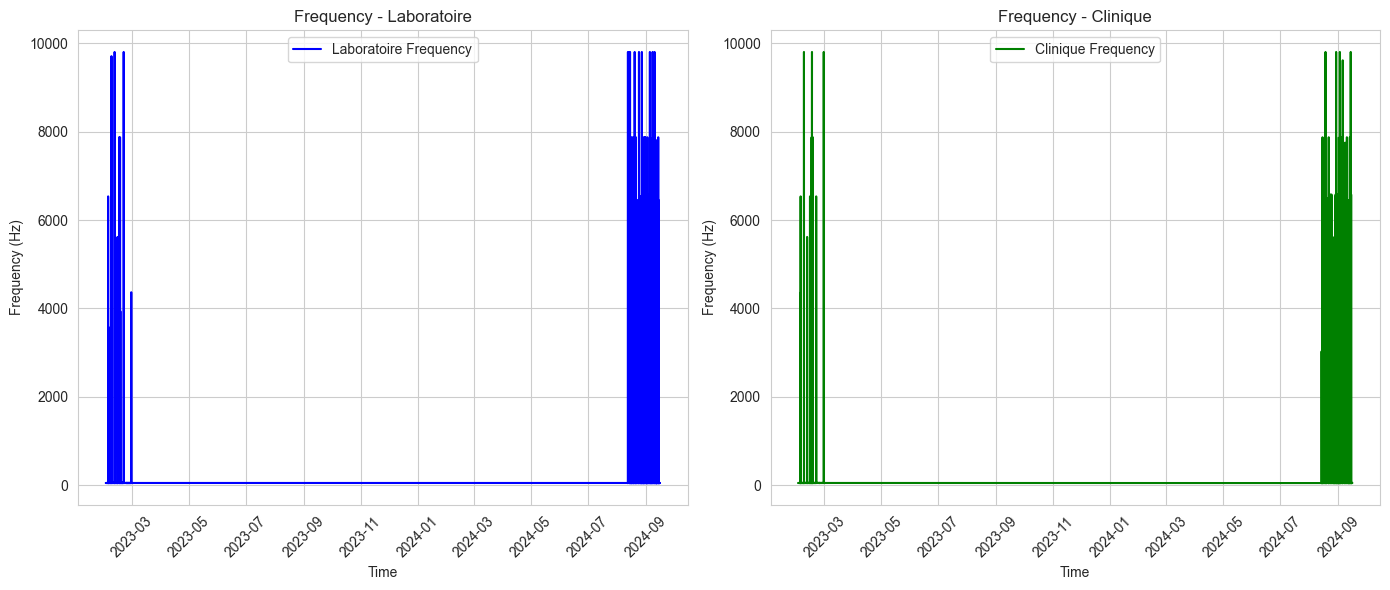

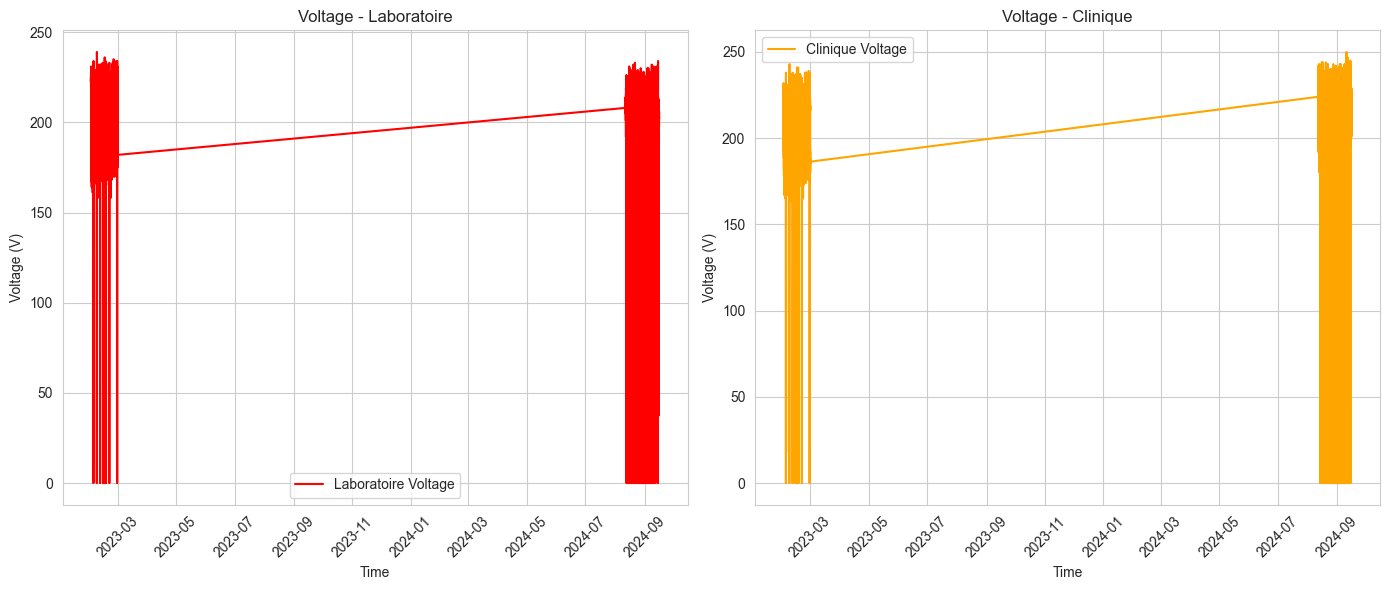

In [8]:
# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'])

# Plot Frequency for both facilities
plt.figure(figsize=(14, 6))

# Plot Frequency for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data['Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label='Laboratoire Frequency', color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Frequency for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data['Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'], label='Clinique Frequency', color='green')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Plot Voltage for both facilities
plt.figure(figsize=(14, 6))

# Plot Voltage for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label='Laboratoire Voltage', color='red')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Voltage for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data['Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'], label='Clinique Voltage', color='orange')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# List of columns to calculate statistics
columns_of_interest = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]

# Calculate the statistics for each column, including mean, median, percentiles, and null counts
stats = data[columns_of_interest].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.01),  # 1st percentile
    lambda x: x.quantile(0.99),  # 99th percentile
    lambda x: x.isnull().sum()/x.sum()*100  # Null counts
])

# Renaming the lambda output columns
stats.columns = columns_of_interest
stats.index = ['Mean', 'Median', '1st Percentile', '99th Percentile', 'Null Count (%)']

# Display the statistics
print(stats)

                 Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)  \
Mean                                                     72.947477            
Median                                                   50.100000            
1st Percentile                                           49.000000            
99th Percentile                                          52.100000            
Null Count (%)                                            0.000091            

                 Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)  \
Mean                                                     80.850821         
Median                                                   50.100000         
1st Percentile                                           49.000000         
99th Percentile                                          52.400000         
Null Count (%)                                            0.000027         

                 Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laborat

# 2. Training and Test Data Separation

In [10]:
# Determine the split index (60% for training)
split_index = int(len(data) * 0.6)

# Split the data into training and testing sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Display the sizes of the train and test sets
print(f'Training data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

# Optionally, display the first few rows of each
print("Training Data Sample:")
display(train_data)

print("Test Data Sample:")
display(test_data)

Training data size: 27216
Test data size: 18144
Training Data Sample:


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False
...,...,...,...,...,...,...
27211,2024-08-21 05:02:00,49.8,49.9,213.0,233.0,False
27212,2024-08-21 05:04:00,49.9,50.0,211.0,233.0,False
27213,2024-08-21 05:06:00,49.8,49.8,214.0,233.0,False
27214,2024-08-21 05:08:00,49.7,49.7,211.0,232.0,False


Test Data Sample:


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False
...,...,...,...,...,...,...
45355,2024-09-09 09:50:00,49.6,49.5,194.0,196.0,False
45356,2024-09-09 09:52:00,49.5,49.5,197.0,197.0,False
45357,2024-09-09 09:54:00,49.7,49.6,196.0,195.0,False
45358,2024-09-09 09:56:00,49.3,49.3,196.0,193.0,False


# 3. Voltage and Frequency Only 

#### *3.1. Baseline Model on the Voltage and Frequency only*

-> Choosing only the most from the train set

In [11]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

In [12]:
train_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5
test_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5

display('Train data for baseline:')
display(train_data_base['prediction'])

display('Test data for baseline:')
display(test_data_base['prediction'])

'Train data for baseline:'

0        False
1        False
2        False
3        False
4        False
         ...  
27211    False
27212    False
27213    False
27214    False
27215    False
Name: prediction, Length: 27216, dtype: bool

'Test data for baseline:'

27216    False
27217    False
27218    False
27219    False
27220    False
         ...  
45355    False
45356    False
45357    False
45358    False
45359    False
Name: prediction, Length: 18144, dtype: bool

Assessing the model:

In [13]:
# TRAIN DATA EVALUATION
metrics = evaluate_model_performance(train_data_base)

Accuracy of model: 0.8528439153439153
Confusion Matrix:
[[23211     0]
 [ 4005     0]]
Precision of model: 0.0
Recall of model: 0.0


In [14]:
# TEST DATA EVALUATION
metrics = evaluate_model_performance(test_data_base)

Accuracy of model: 0.8170194003527337
Confusion Matrix:
[[14824     0]
 [ 3320     0]]
Precision of model: 0.0
Recall of model: 0.0


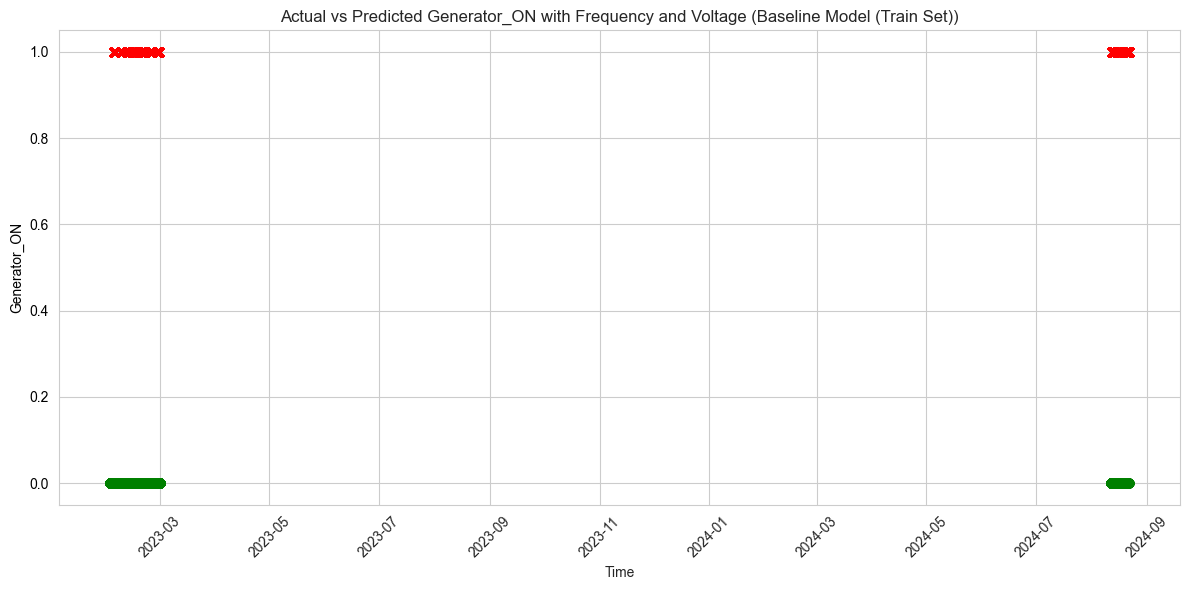

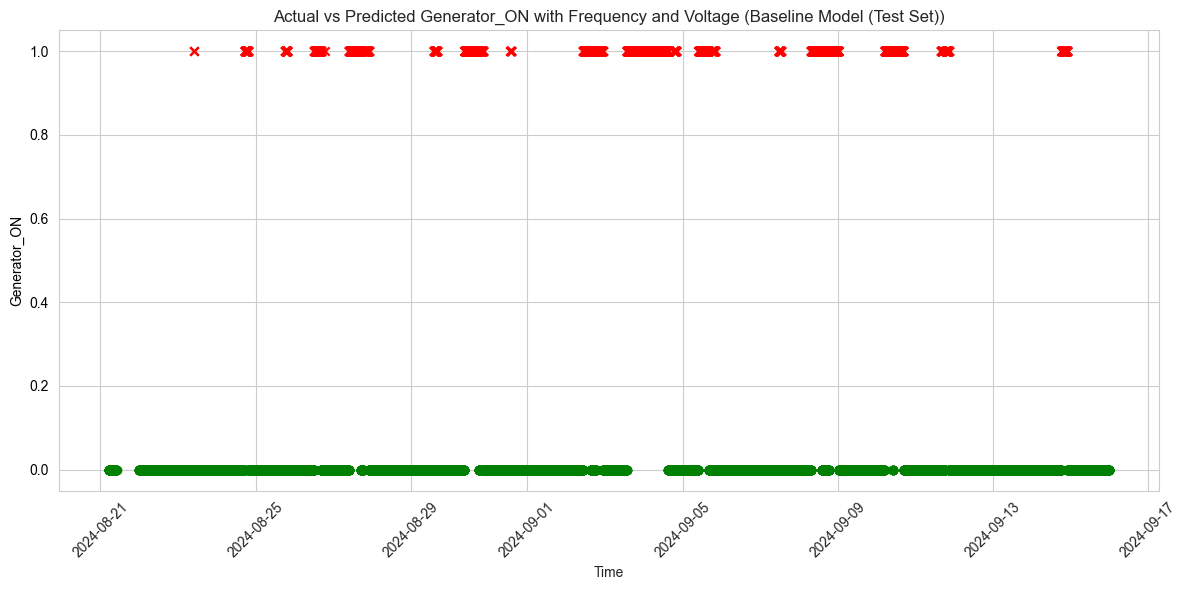

In [15]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)", include_voltage=False, include_frequency=False)

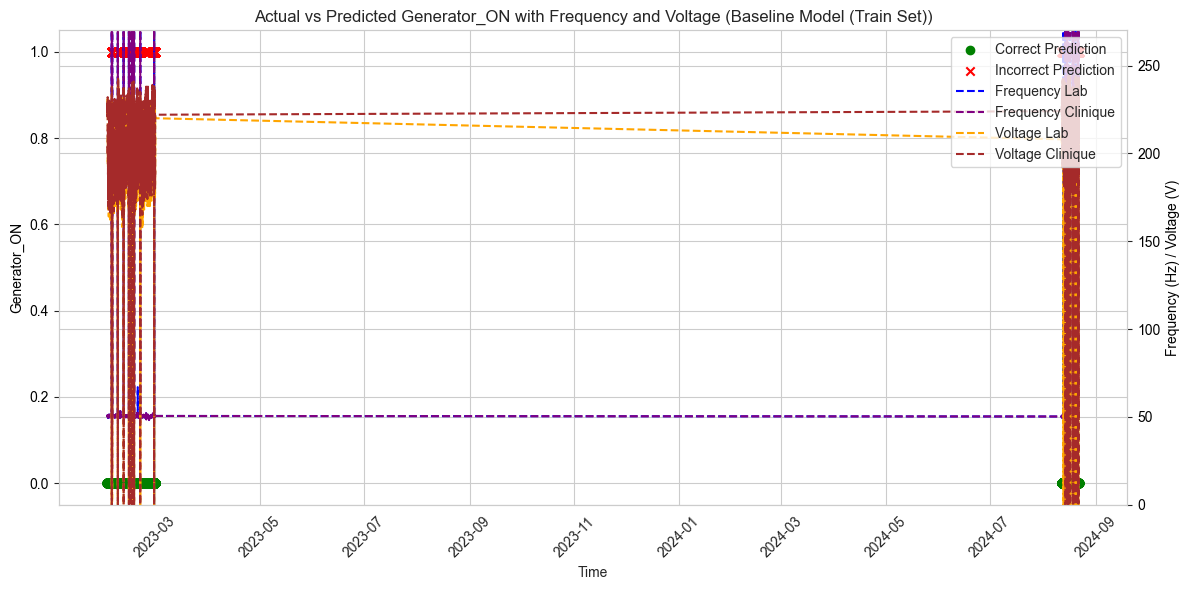

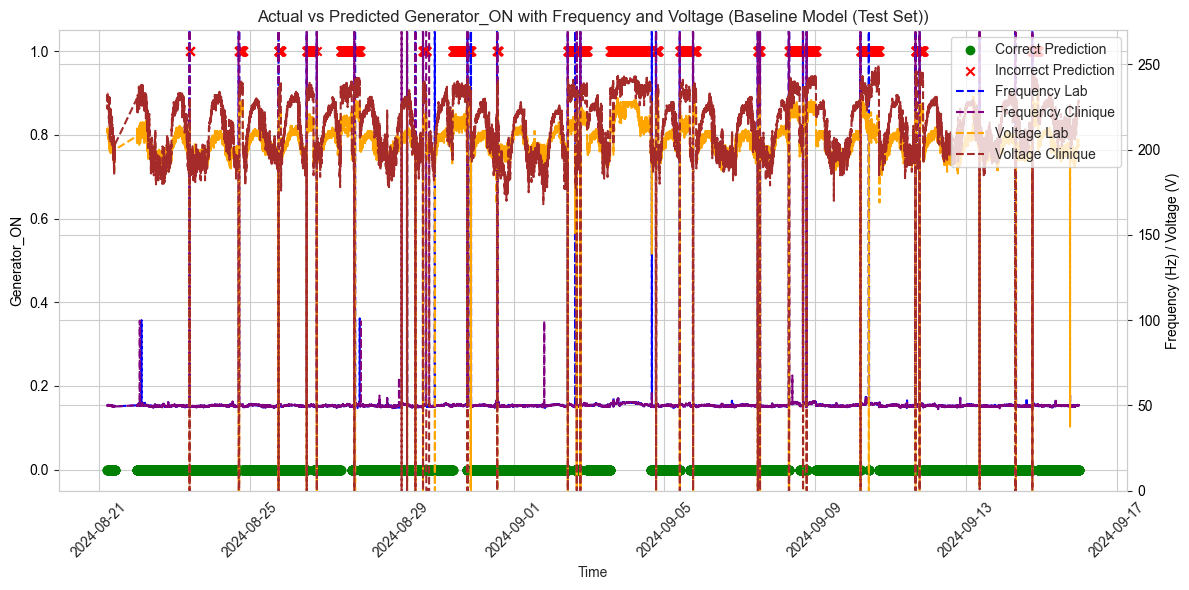

In [16]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)", include_voltage=True, include_frequency=True)

#### *3.2. Logistic Regression on the Voltage and Frequency only*

In [17]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.85
Test Accuracy: 0.82


Evaluating the train set - Baseline Logistic Regression:

In [18]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8515579071134627
Confusion Matrix:
[[23172    39]
 [ 4001     4]]
Precision: 0.09302325581395349
Recall: 0.0009987515605493133
Train data prediction distribution:
prediction
0    27173
1       43
Name: count, dtype: int64


Evaluating the test set - Baseline Logistic Regression:

In [19]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.8210427689594356
Confusion Matrix:
[[14789    35]
 [ 3212   108]]
Precision: 0.7552447552447552
Recall: 0.03253012048192771
Test data prediction distribution:
prediction
0    18001
1      143
Name: count, dtype: int64


#### *3.3. Random Forrest on the Voltage and Frequency only*

In [20]:
# Step 1: Create copies of the original data
train_data_rf = train_data.copy()
test_data_rf = test_data.copy()

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_rf[feature_columns]
y_train = train_data_rf['Generator_ON']

X_test = test_data_rf[feature_columns]
y_test = test_data_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_rf['prediction'] = clf.predict(X_train)
test_data_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [21]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9971340388007055
Confusion Matrix:
[[23186    25]
 [   53  3952]]
Precision: 0.9937138546643198
Recall: 0.9867665418227216
Train data prediction distribution:
prediction
False    23239
True      3977
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [22]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9639550264550265
Confusion Matrix:
[[14673   151]
 [  503  2817]]
Precision: 0.9491239892183289
Recall: 0.8484939759036144
Test data prediction distribution:
prediction
False    15176
True      2968
Name: count, dtype: int64


#### *3.4. XG-Boost on the Voltage and Frequency only*

Top 20 features sorted by importance (XGBoost):


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.800886
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.110703
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.052324
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.036086


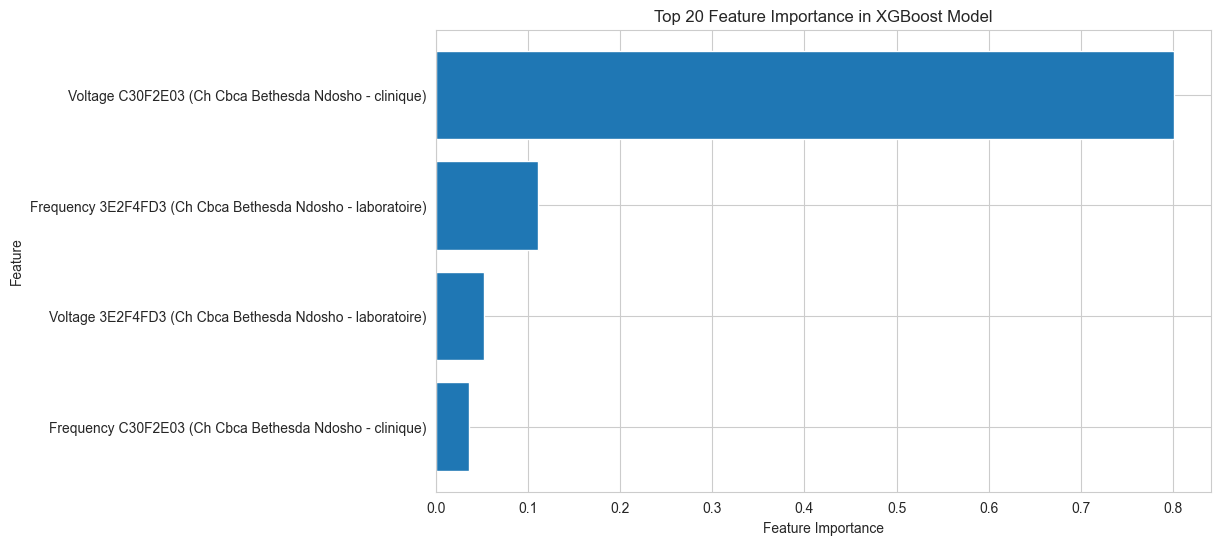

In [23]:
# Step 0: Copy rf data
train_data_boost = train_data.copy()
test_data_boost = test_data.copy()

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]


# Step 1: Use the same data and feature columns
X_train = train_data_boost[feature_columns]
y_train = train_data_boost['Generator_ON']

X_test = test_data_boost[feature_columns]
y_test = test_data_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_boost['prediction'] = xgb_clf.predict(X_train)
test_data_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [24]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9932760141093474
Confusion Matrix:
[[23144    67]
 [  116  3889]]
Precision: 0.9830637007077856
Recall: 0.9710362047440699
Train data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


In [25]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9664351851851852
Confusion Matrix:
[[14679   145]
 [  464  2856]]
Precision: 0.951682772409197
Recall: 0.8602409638554217
Test data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


# 4. Feature Generation

### 4.1. Using Mean as a Threshold

In [26]:
train_data_mean = train_data.copy()
test_data_mean = test_data.copy()

In [27]:
# Taking the mean of the dataframe
train_data_mean, test_data_mean = calculate_mean_flags(train_data_mean, test_data_mean, train_data_base, columns_to_compare)

# Display the updated data
display(train_data_mean)
display(test_data_mean)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False,False,False,True,True
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False,False,False,True,True
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False,False,False,True,True
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False,False,False,True,True
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
27211,2024-08-21 05:02:00,49.8,49.9,213.0,233.0,False,False,False,True,True
27212,2024-08-21 05:04:00,49.9,50.0,211.0,233.0,False,False,False,True,True
27213,2024-08-21 05:06:00,49.8,49.8,214.0,233.0,False,False,False,True,True
27214,2024-08-21 05:08:00,49.7,49.7,211.0,232.0,False,False,False,True,True


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False,False,False,True,True
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False,False,False,True,True
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False,False,False,True,True
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False,False,False,True,True
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
45355,2024-09-09 09:50:00,49.6,49.5,194.0,196.0,False,False,False,False,False
45356,2024-09-09 09:52:00,49.5,49.5,197.0,197.0,False,False,False,False,False
45357,2024-09-09 09:54:00,49.7,49.6,196.0,195.0,False,False,False,False,False
45358,2024-09-09 09:56:00,49.3,49.3,196.0,193.0,False,False,False,False,False


#### 4.1.1. Using Mean as a Threshold - Custom Prediction

In [28]:
# Define custom prediction logic
def custom_prediction(row):
    # Example: Set prediction to True if either clinic or lab has higher frequency and voltage
    if (row['higher_freq_lab'] or row['higher_volt_lab']) and (row['higher_freq_clinique'] or row['higher_volt_clinique']):
        return True
    else:
        return False

# Apply custom prediction logic
train_data_mean['prediction'] = train_data_mean.apply(custom_prediction, axis=1)
test_data_mean['prediction'] = test_data_mean.apply(custom_prediction, axis=1)

# Show prediction:
display('Train data for baseline:')
display(train_data_mean['prediction'].value_counts())

display('Test data for baseline:')
display(test_data_mean['prediction'].value_counts())

'Train data for baseline:'

prediction
False    13723
True     13493
Name: count, dtype: int64

'Test data for baseline:'

prediction
False    9536
True     8608
Name: count, dtype: int64

Assessing the mean model: 

In [29]:
metrics = evaluate_model_performance(train_data_mean)

Accuracy of model: 0.6511610817166372
Confusion Matrix:
[[13720  9491]
 [    3  4002]]
Precision of model: 0.29659823612243386
Recall of model: 0.9992509363295881


In [30]:
metrics = evaluate_model_performance(test_data_mean)

Accuracy of model: 0.7081128747795414
Confusion Matrix:
[[9532 5292]
 [   4 3316]]
Precision of model: 0.38522304832713755
Recall of model: 0.9987951807228915


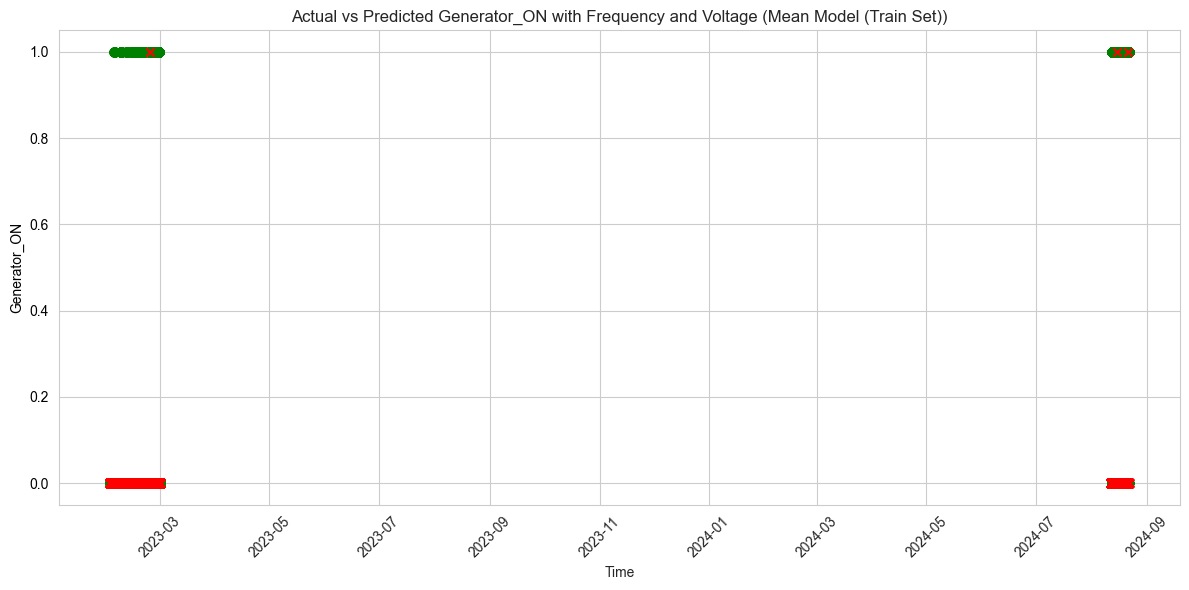

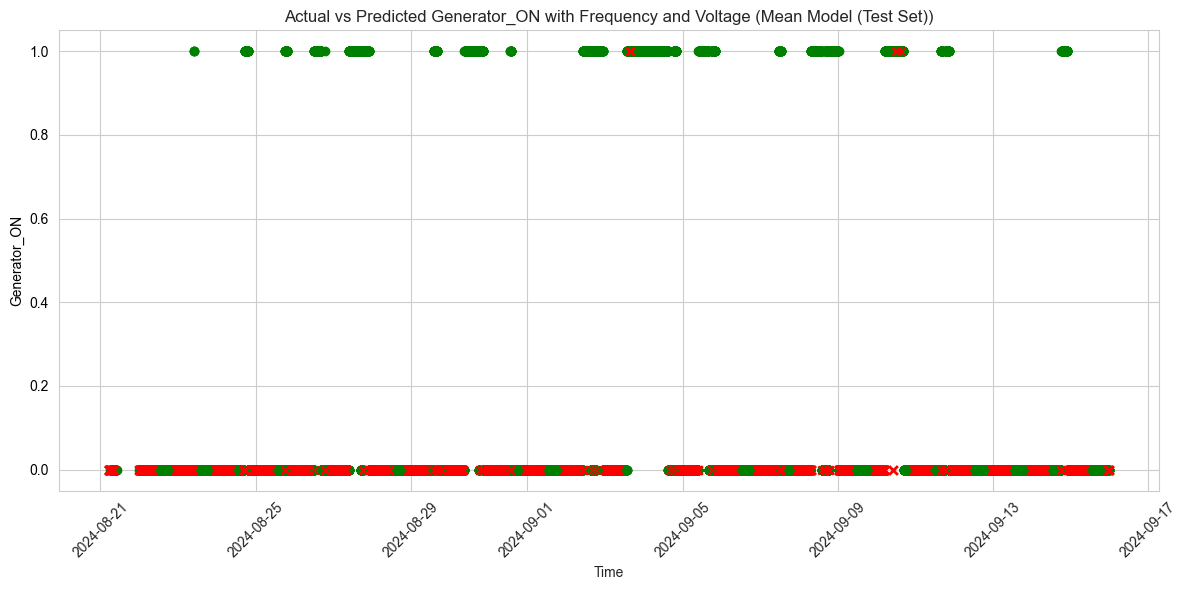

In [31]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)", include_voltage=False, include_frequency=False)

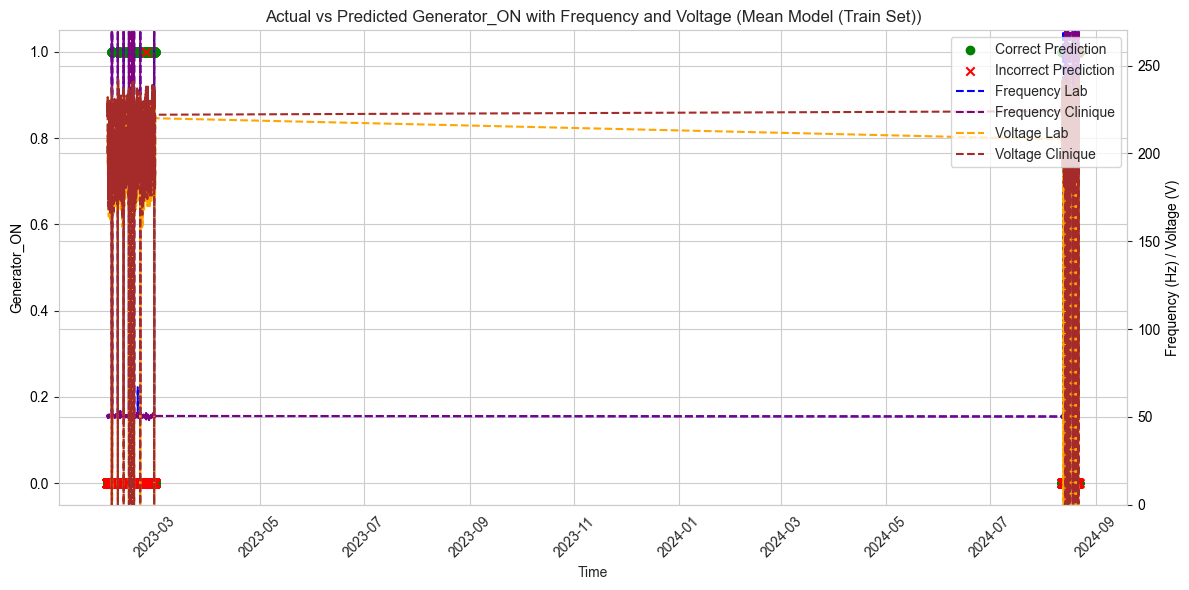

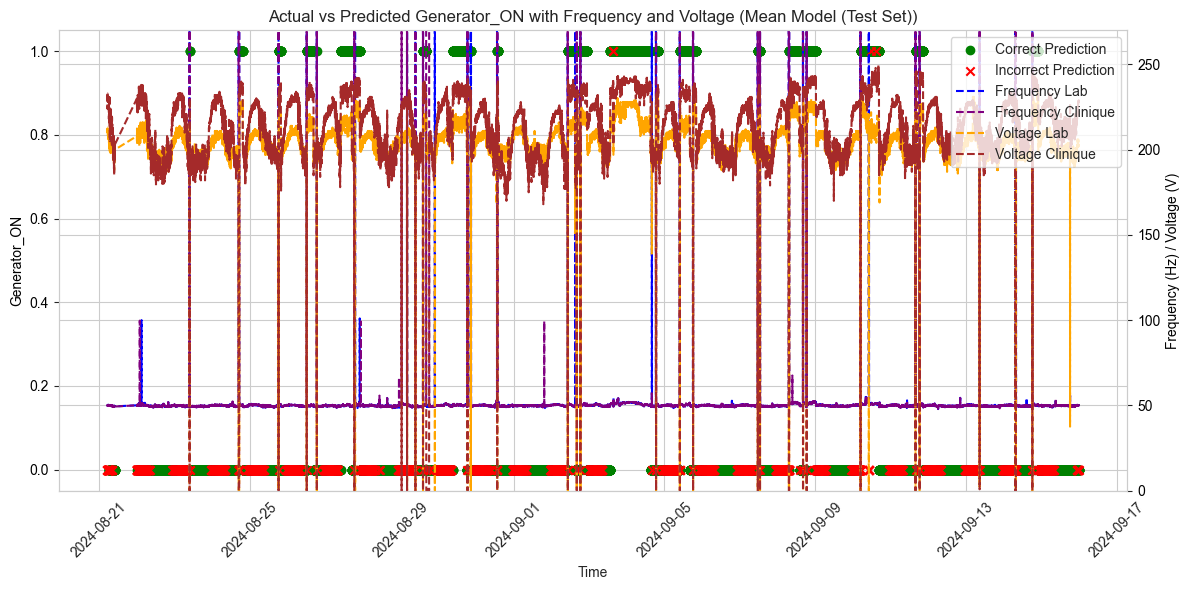

In [32]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)", include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)", include_voltage=True, include_frequency=True)

#### 4.1.2. Using Mean as a Threshold - Logistic Regression

In [33]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.89
Test Accuracy: 0.91


Evaluating the train set (Logistic Regression): 

In [34]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8907260435038212
Confusion Matrix:
[[23130    81]
 [ 2893  1112]]
Precision: 0.9321039396479464
Recall: 0.2776529338327091
Train data prediction distribution:
prediction
0    26023
1     1193
Name: count, dtype: int64


Evaluating the test set (Logistic Regression): 

In [35]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9115961199294532
Confusion Matrix:
[[14722   102]
 [ 1502  1818]]
Precision: 0.946875
Recall: 0.5475903614457831
Test data prediction distribution:
prediction
0    16224
1     1920
Name: count, dtype: int64


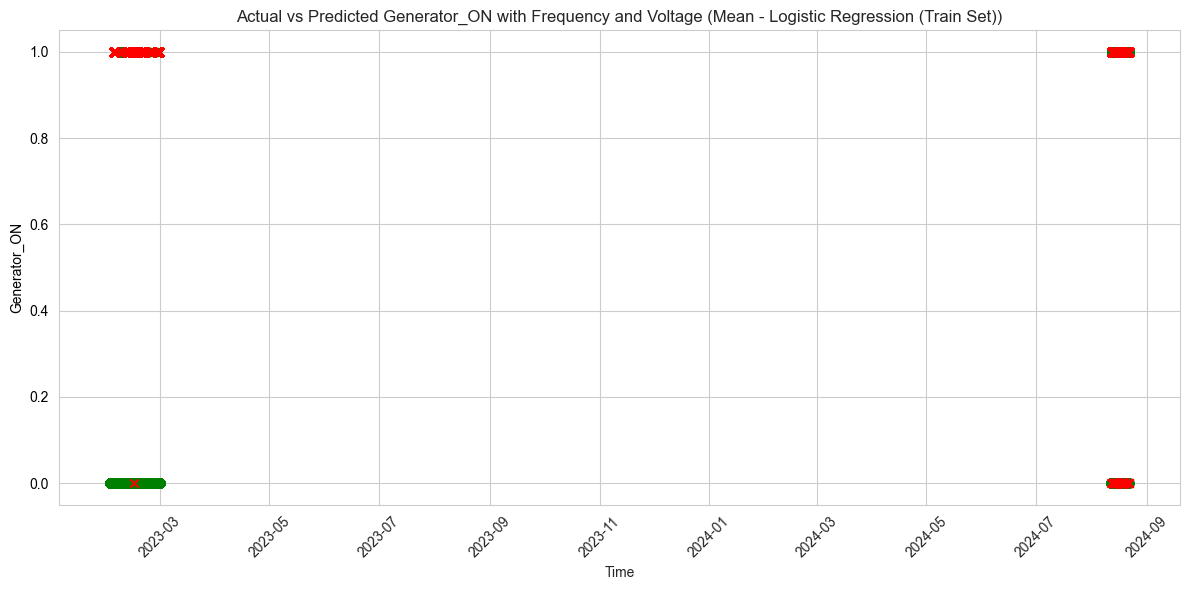

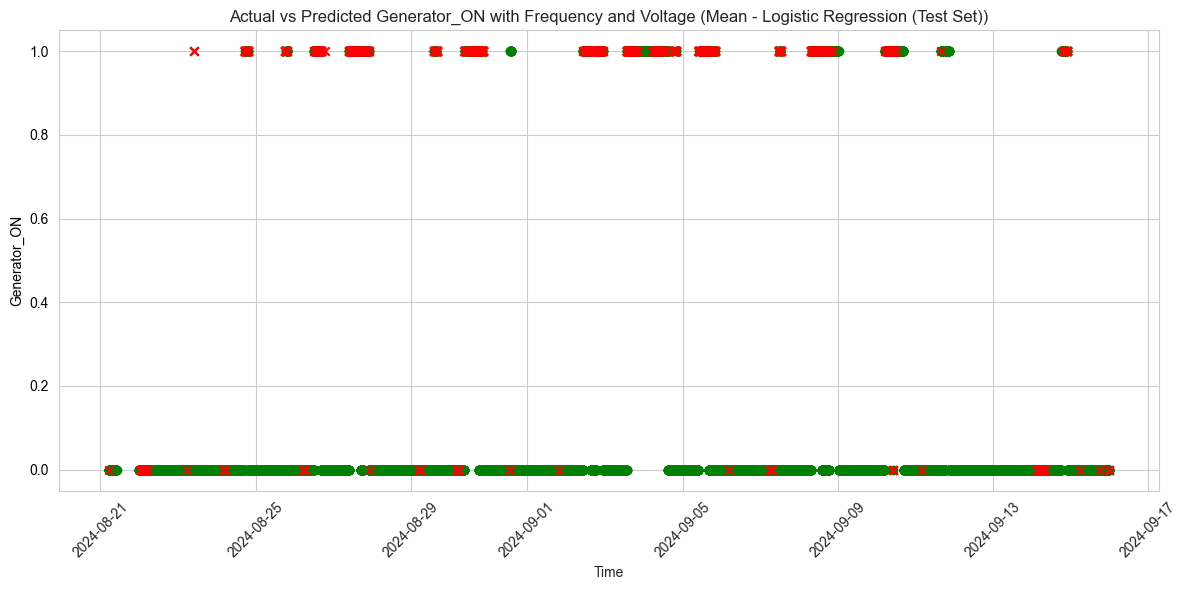

In [36]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)", include_voltage=False, include_frequency=False)

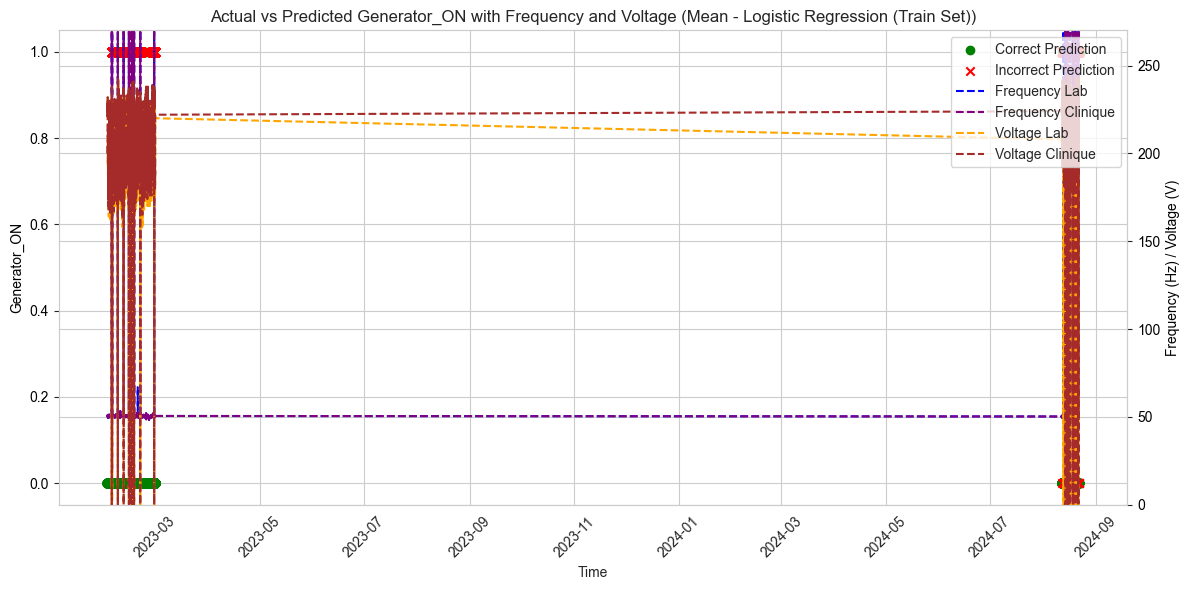

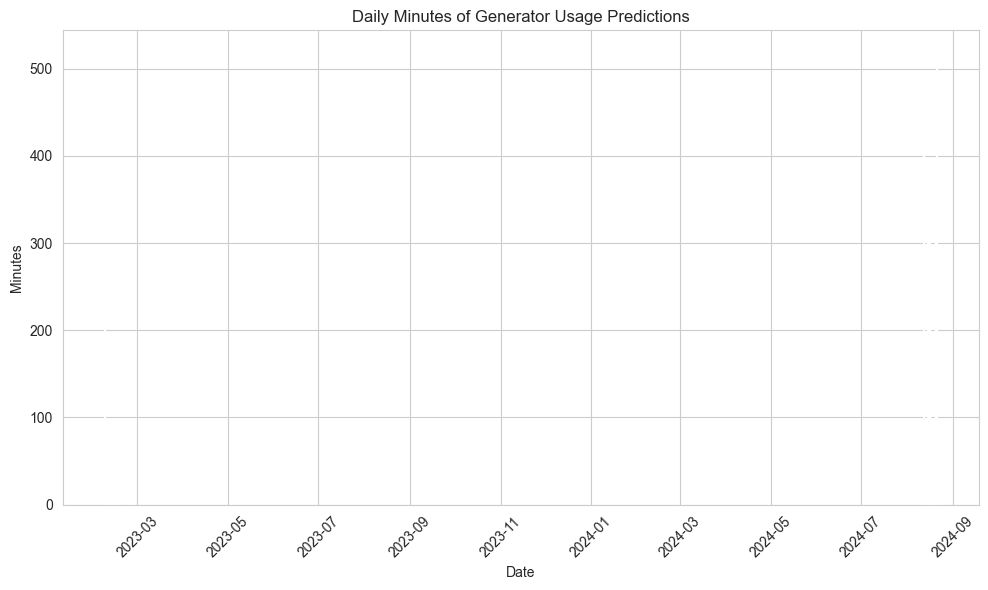

,Date,Count,Minutes,Hours
0,2023-02-07,108,216,3.600000
1,2023-02-14,1,2,0.033333
2,2023-02-15,6,12,0.200000
3,2023-02-16,4,8,0.133333
4,2023-02-23,1,2,0.033333
5,2023-02-27,1,2,0.033333
6,2024-08-12,206,412,6.866667
7,2024-08-13,34,68,1.133333
8,2024-08-14,16,32,0.533333
9,2024-08-15,182,364,6.066667


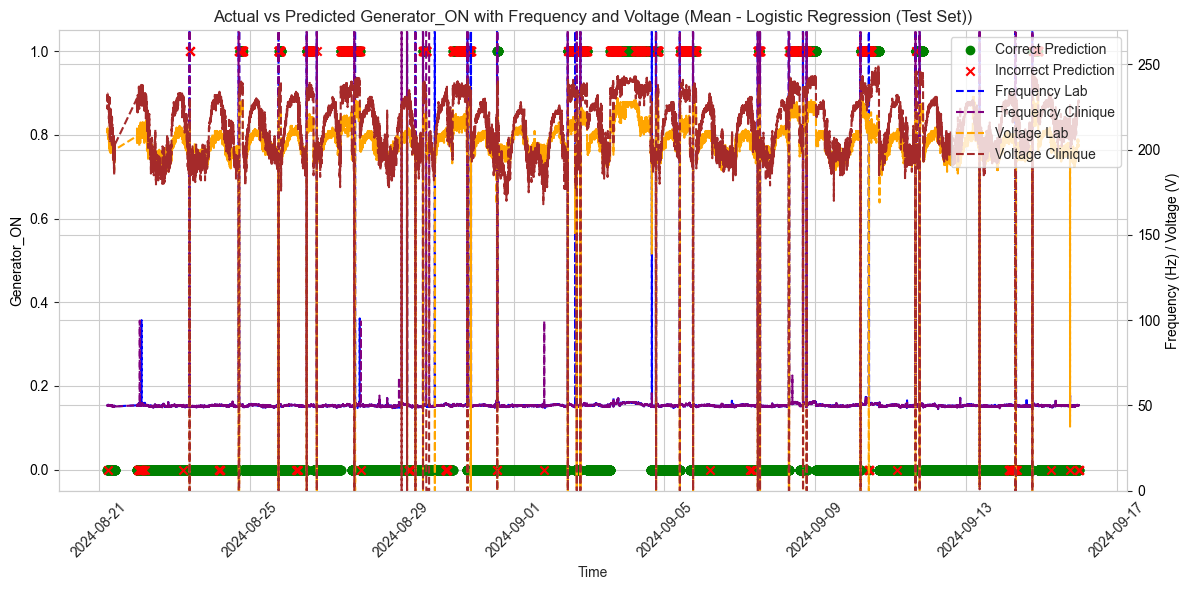

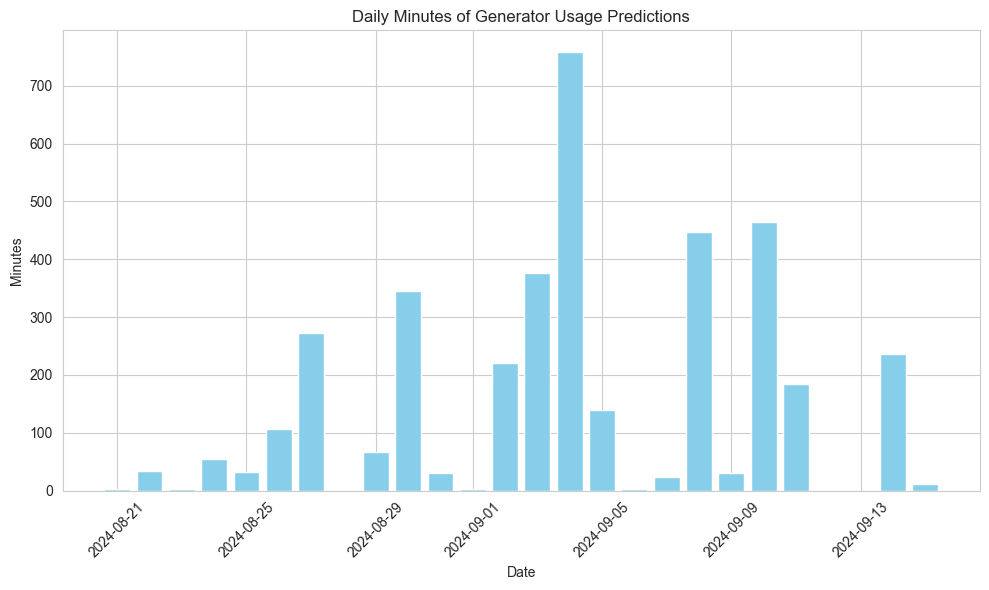

,Date,Count,Minutes,Hours
0,2024-08-21,1,2,0.033333
1,2024-08-22,17,34,0.566667
2,2024-08-23,1,2,0.033333
3,2024-08-24,27,54,0.900000
4,2024-08-25,16,32,0.533333
5,2024-08-26,53,106,1.766667
6,2024-08-27,136,272,4.533333
7,2024-08-29,33,66,1.100000
8,2024-08-30,173,346,5.766667
9,2024-08-31,15,30,0.500000


In [37]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)", include_voltage=True, include_frequency=True)
train_data_lg_daily_count = plot_true_predictions_histogram(train_data_mean_lg)
display(train_data_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)", include_voltage=True, include_frequency=True)
test_data_lg_daily_count = plot_true_predictions_histogram(test_data_mean_lg)
display(test_data_lg_daily_count)

#### 4.1.3. Using Mean as a Threshold - Random Forrest

In [38]:
# Step 1: Create copies of the original data
train_data_mean_rf = train_data.copy()
test_data_mean_rf = test_data.copy()

# Taking the mean of the dataframe
train_data_mean_rf, test_data_mean_rf = calculate_mean_flags(train_data_mean_rf, test_data_mean_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_rf[feature_columns]
y_train = train_data_mean_rf['Generator_ON']

X_test = test_data_mean_rf[feature_columns]
y_test = test_data_mean_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_rf['prediction'] = clf.predict(X_train)
test_data_mean_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [39]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9971340388007055
Confusion Matrix:
[[23189    22]
 [   56  3949]]
Precision: 0.9944598337950139
Recall: 0.9860174781523097
Train data prediction distribution:
prediction
False    23245
True      3971
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [40]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9662698412698413
Confusion Matrix:
[[14692   132]
 [  480  2840]]
Precision: 0.955585464333782
Recall: 0.8554216867469879
Test data prediction distribution:
prediction
False    15172
True      2972
Name: count, dtype: int64


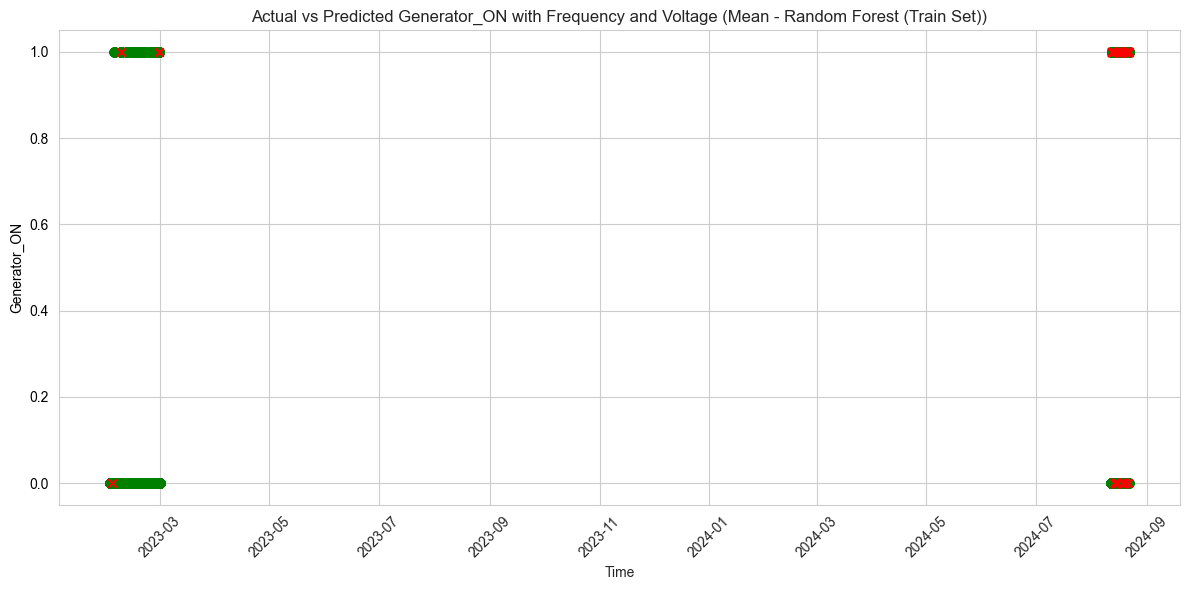

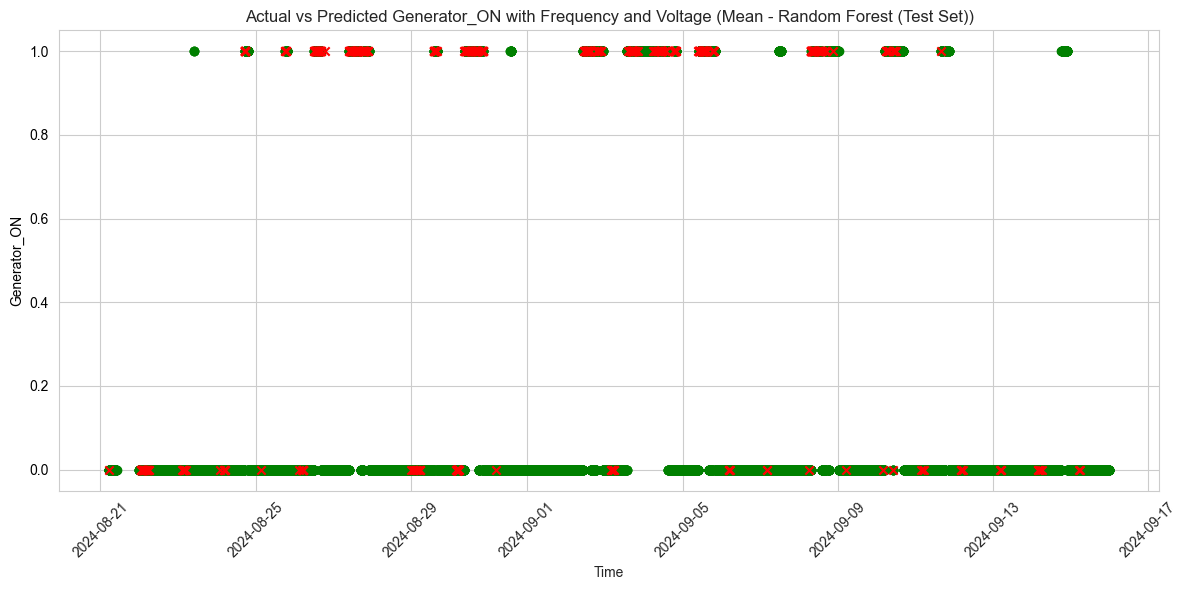

In [41]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=False, include_frequency=False)

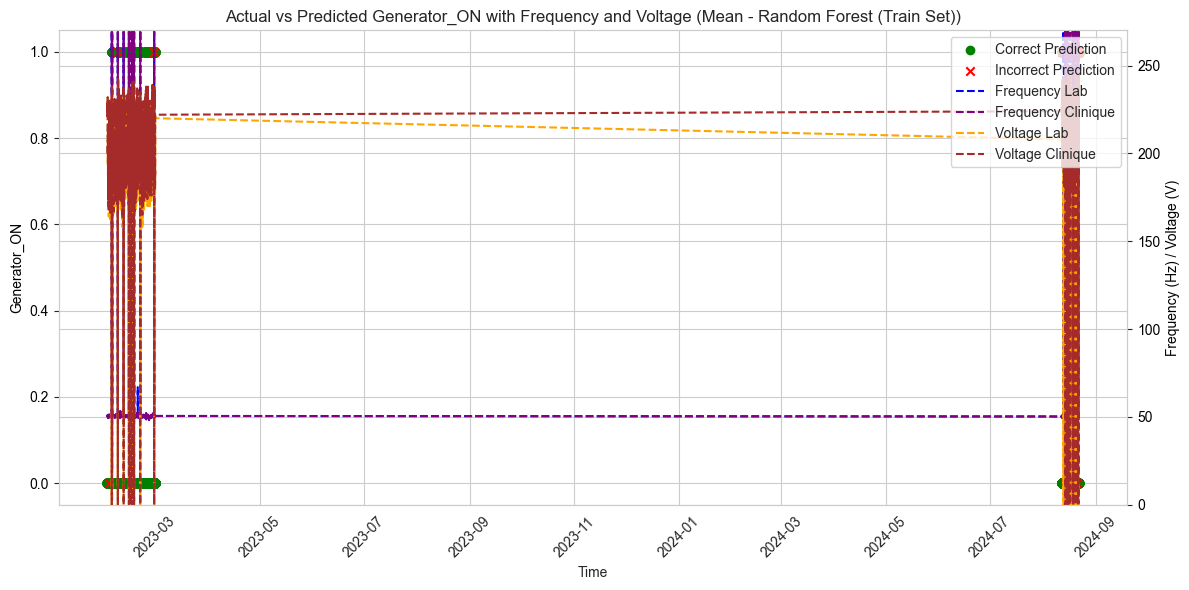

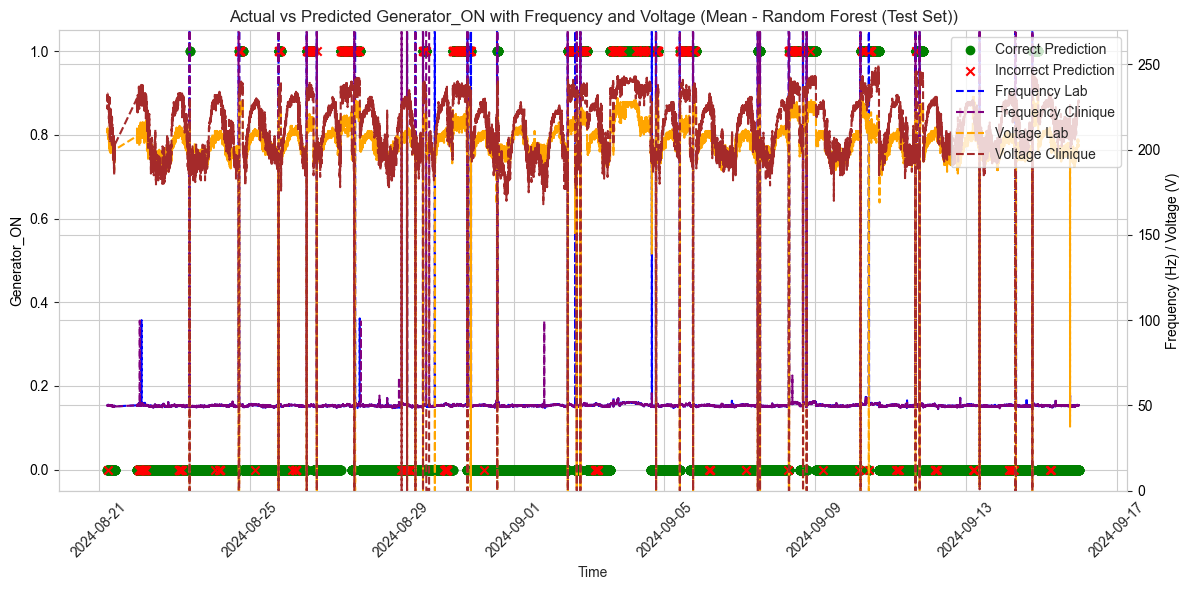

In [42]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=True, include_frequency=True)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=True, include_frequency=True)

In [43]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_rf)
display_generator_statistics(test_data_mean_rf)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 3971 minutes, or 66.18 hours within 453.60 hours
Actual Minutes: 3320 minutes, or 55.33 hours within 302.40 hours
Predicted Minutes: 2972 minutes, or 49.53 hours within 302.40 hours


#### 4.1.4. Using Mean as a Threshold - XGBoost

Top 20 features sorted by importance (XGBoost):


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.800886
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.110703
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.052324
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.036086
4,higher_freq_lab,0.000000
5,higher_freq_clinique,0.000000
6,higher_volt_lab,0.000000
7,higher_volt_clinique,0.000000


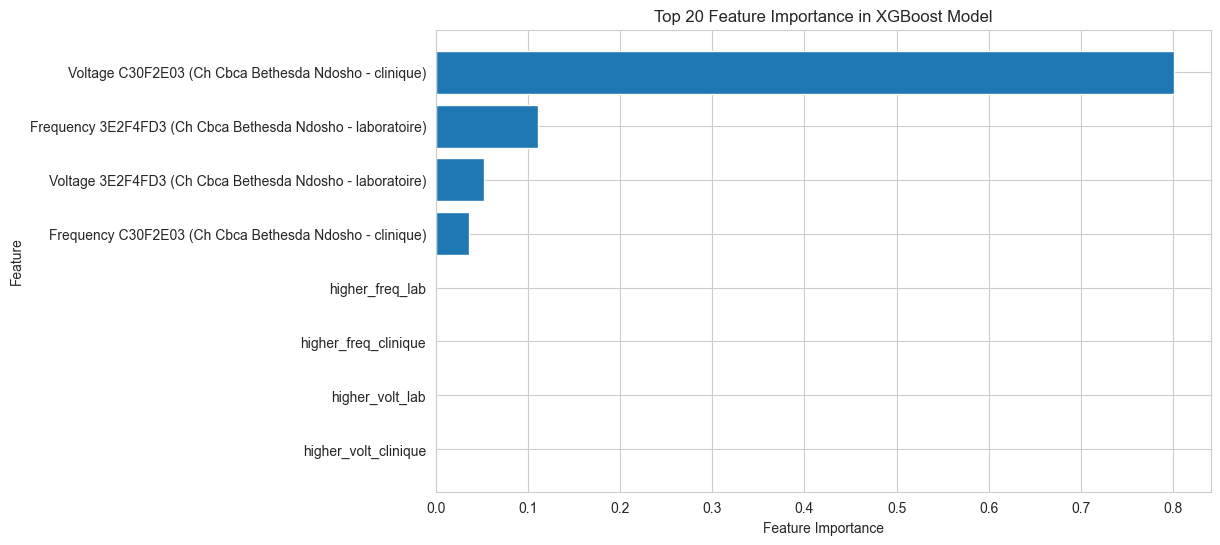

In [44]:
# Step 0: Copy rf data
train_data_mean_boost = train_data.copy()
test_data_mean_boost = test_data.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_mean_boost, test_data_mean_boost = calculate_mean_flags(train_data_mean_boost, test_data_mean_boost, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_mean_boost[feature_columns]
y_train = train_data_mean_boost['Generator_ON']

X_test = test_data_mean_boost[feature_columns]
y_test = test_data_mean_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_boost['prediction'] = xgb_clf.predict(X_train)
test_data_mean_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [45]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_mean_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9932760141093474
Confusion Matrix:
[[23144    67]
 [  116  3889]]
Precision: 0.9830637007077856
Recall: 0.9710362047440699
Train data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


In [46]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_mean_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9664351851851852
Confusion Matrix:
[[14679   145]
 [  464  2856]]
Precision: 0.951682772409197
Recall: 0.8602409638554217
Test data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


In [47]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_boost)
display_generator_statistics(test_data_mean_boost)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 3956 minutes, or 65.93 hours within 453.60 hours
Actual Minutes: 3320 minutes, or 55.33 hours within 302.40 hours
Predicted Minutes: 3001 minutes, or 50.02 hours within 302.40 hours


### 4.2. Generating Time Series Feature

In [48]:
## INITIALIZATION OF CONSTANTS
# Range of reasonable frequency and voltage
high_freq_threshold = 60
low_freq_threshold = 40

high_volt_threshold = 250
low_volt_threshold = 2

voltage_delta = 10

In [49]:
train_data_ts = train_data.copy()
test_data_ts = test_data.copy()

In [50]:
## FEATURE GENERATION
# Using mean to compare
train_data_ts, test_data_ts = calculate_mean_flags(train_data_ts, test_data_ts, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
train_data_ts, test_data_ts = process_time_series_data(train_data_ts, test_data_ts, high_freq_threshold, low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display the processed data
display(train_data_ts)
display(test_data_ts)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27211,2024-08-21 05:02:00,49.8,49.9,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27212,2024-08-21 05:04:00,49.9,50.0,211.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27213,2024-08-21 05:06:00,49.8,49.8,214.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27214,2024-08-21 05:08:00,49.7,49.7,211.0,232.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45355,2024-09-09 09:50:00,49.6,49.5,194.0,196.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45356,2024-09-09 09:52:00,49.5,49.5,197.0,197.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45357,2024-09-09 09:54:00,49.7,49.6,196.0,195.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45358,2024-09-09 09:56:00,49.3,49.3,196.0,193.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
train_data_ts.columns

Index(['Time', 'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
       'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
       'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
       'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 'Generator_ON',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
       'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
       'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
       'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
       'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
      

#### 4.2.1. Using Mean of Voltage and Frequency as a Threshold and Time Series - Logistic Regression

Train Accuracy: 0.98
Test Accuracy: 0.97
Top 20 features sorted by absolute coefficient value:


/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
21,Hour_1,-5.748383
22,Hour_2,-5.675688
6,higher_volt_lab,5.537495
20,Hour_0,-5.068832
18,freq_in_range_clinique,-4.888625
19,volt_in_range_clinique,-4.821619
17,volt_in_range_lab,-4.775569
16,freq_in_range_lab,-4.775330
43,Hour_23,-4.402210
7,higher_volt_clinique,4.151784


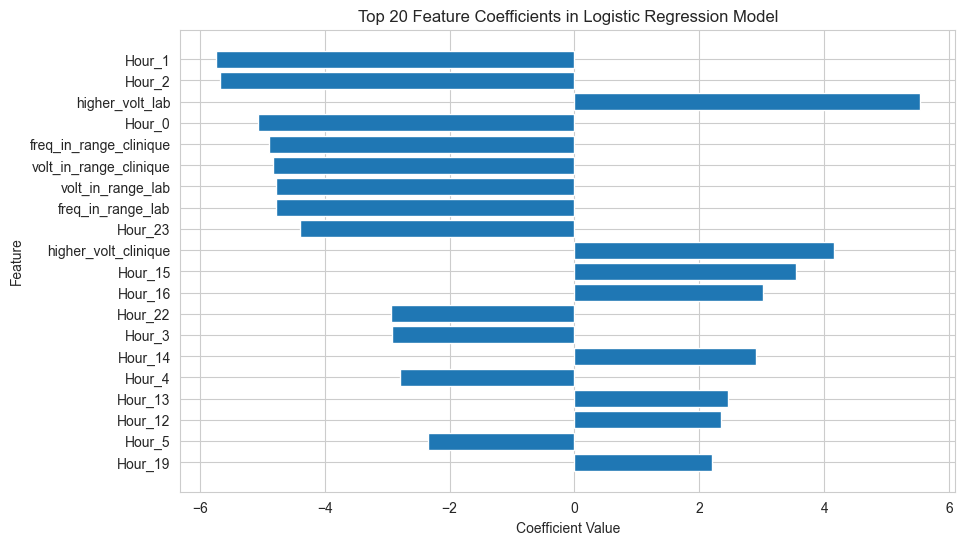

In [52]:

# Step 1: Create copies of the original data
train_data_ts_lg = train_data_ts.copy()
test_data_ts_lg = test_data_ts.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_lg, test_data_ts_lg = calculate_mean_flags(train_data_ts_lg, test_data_ts_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_lg[feature_columns]
y_train = train_data_ts_lg['Generator_ON']

X_test = test_data_ts_lg[feature_columns]
y_test = test_data_ts_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_lg['prediction'] = clf.predict(X_train)
test_data_ts_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [53]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9761169900058789
Confusion Matrix:
[[22965   246]
 [  404  3601]]
Precision: 0.9360540681050169
Recall: 0.8991260923845193
Train data prediction distribution:
prediction
False    23369
True      3847
Name: count, dtype: int64


In [54]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9695767195767195
Confusion Matrix:
[[14788    36]
 [  516  2804]]
Precision: 0.9873239436619718
Recall: 0.844578313253012
Test data prediction distribution:
prediction
False    15304
True      2840
Name: count, dtype: int64


In [55]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_lg)
display_generator_statistics(test_data_ts_lg)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 3847 minutes, or 64.12 hours within 453.60 hours
Actual Minutes: 3320 minutes, or 55.33 hours within 302.40 hours
Predicted Minutes: 2840 minutes, or 47.33 hours within 302.40 hours


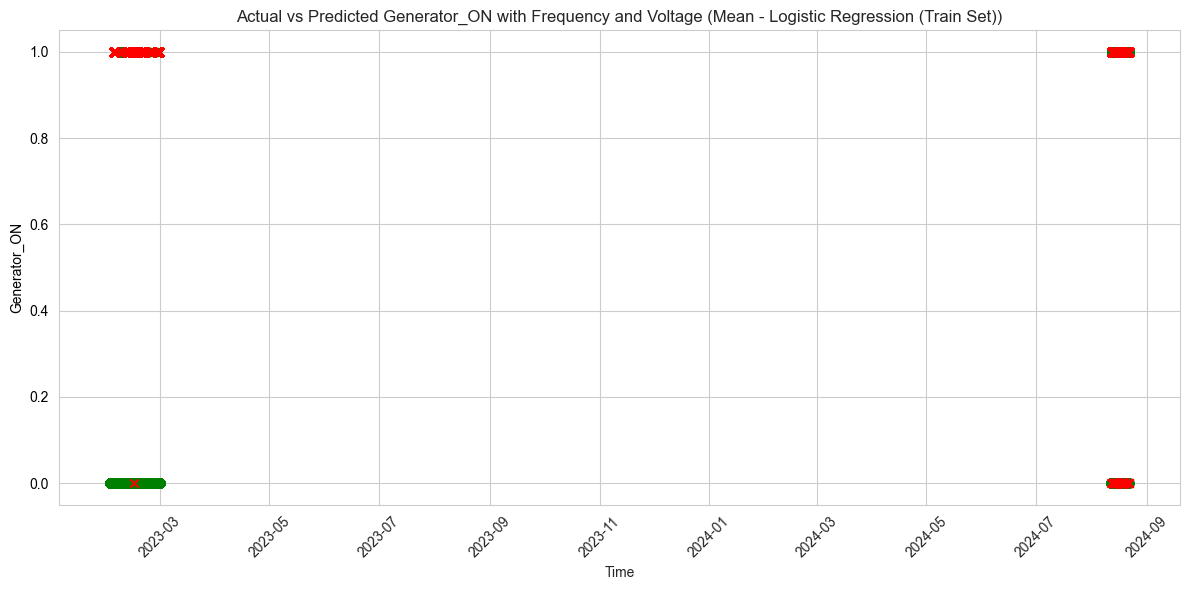

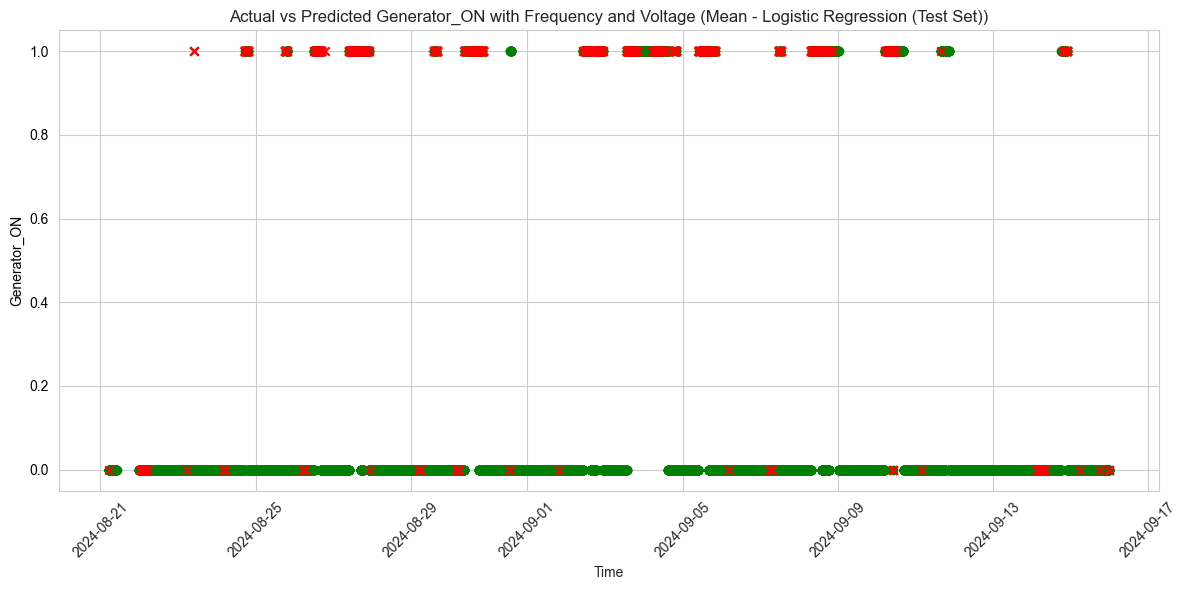

In [56]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)", include_voltage=False, include_frequency=False)

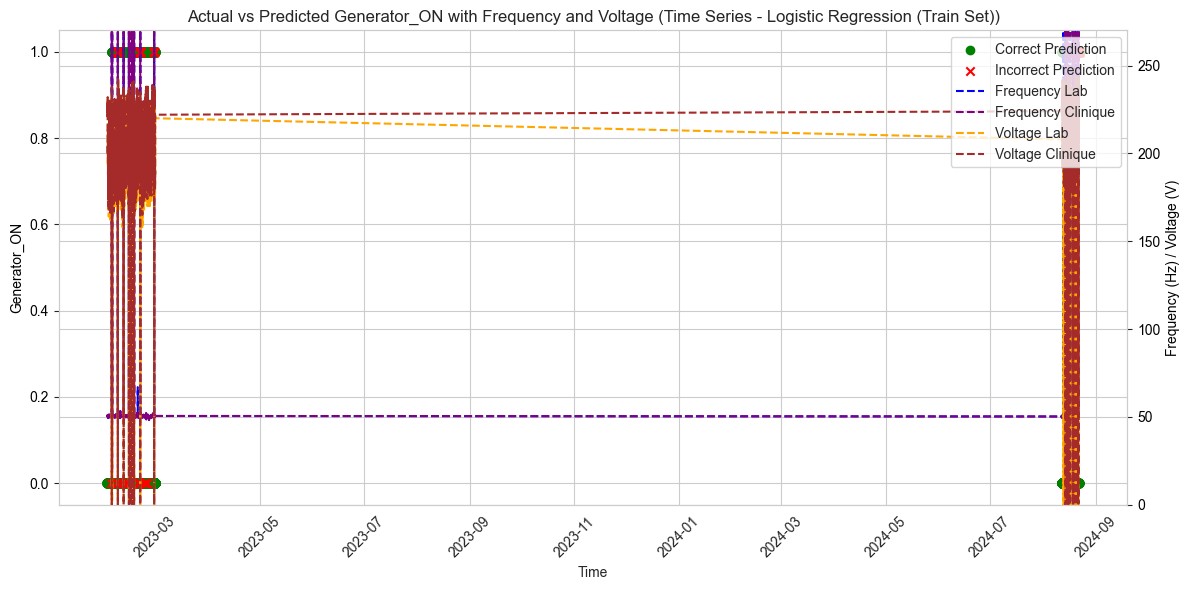

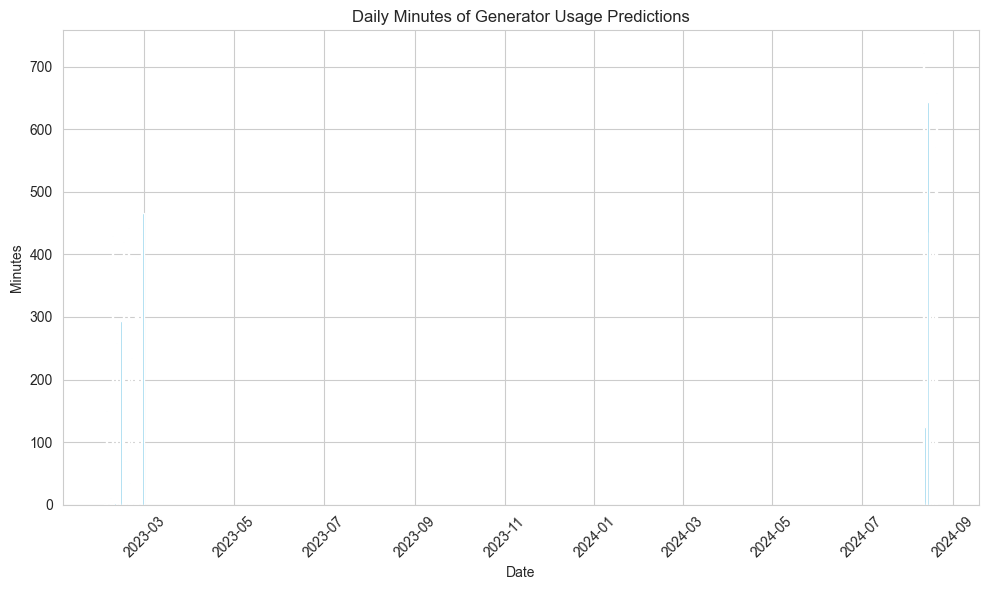

,Date,Count,Minutes,Hours
0,2023-02-02,1,2,0.033333
1,2023-02-03,75,150,2.500000
2,2023-02-06,5,10,0.166667
3,2023-02-07,215,430,7.166667
4,2023-02-09,1,2,0.033333
5,2023-02-10,129,258,4.300000
6,2023-02-12,4,8,0.133333
7,2023-02-13,147,294,4.900000
8,2023-02-14,1,2,0.033333
9,2023-02-15,210,420,7.000000


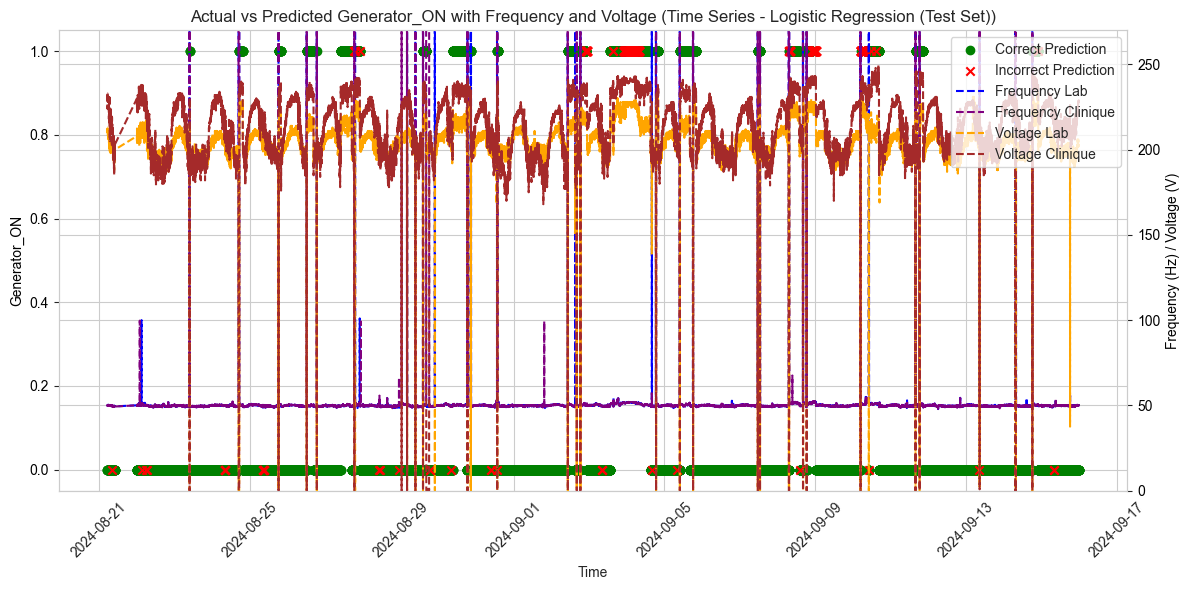

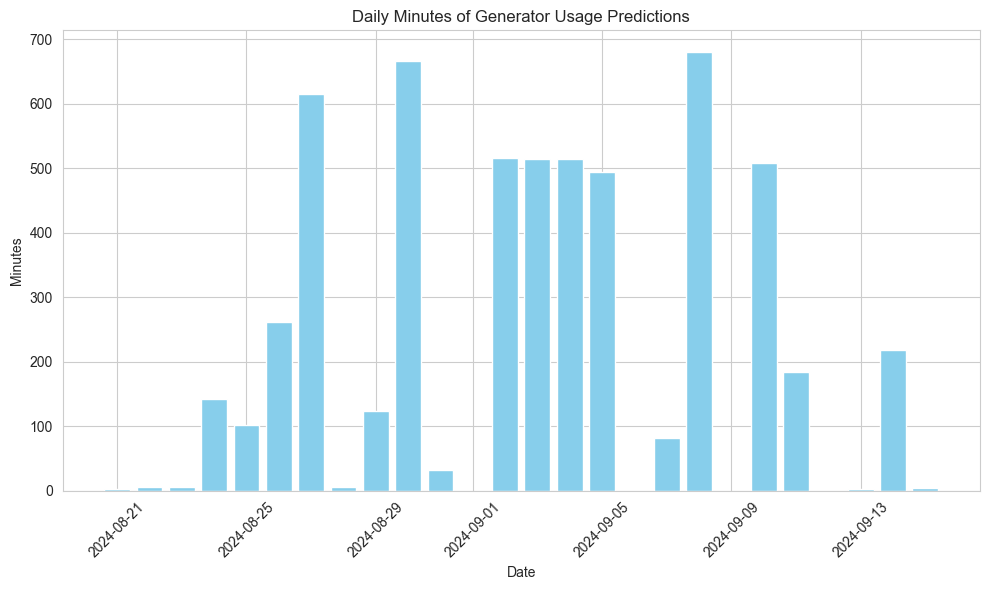

,Date,Count,Minutes,Hours
0,2024-08-21,1,2,0.033333
1,2024-08-22,3,6,0.100000
2,2024-08-23,3,6,0.100000
3,2024-08-24,71,142,2.366667
4,2024-08-25,51,102,1.700000
5,2024-08-26,131,262,4.366667
6,2024-08-27,308,616,10.266667
7,2024-08-28,3,6,0.100000
8,2024-08-29,62,124,2.066667
9,2024-08-30,333,666,11.100000


In [57]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="Time Series - Logistic Regression (Train Set)", include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="Time Series - Logistic Regression (Test Set)", include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)

#### 4.2.2. Using Mean of Voltage and Frequency as a Threshold and Time Series - Random Forrest

Top 15 features sorted by importance:


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.419528
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.148025
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.071939
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.070741
6,higher_volt_lab,0.046275
7,higher_volt_clinique,0.031487
31,Hour_11,0.018083
33,Hour_13,0.014285
34,Hour_14,0.013974
24,Hour_4,0.013622


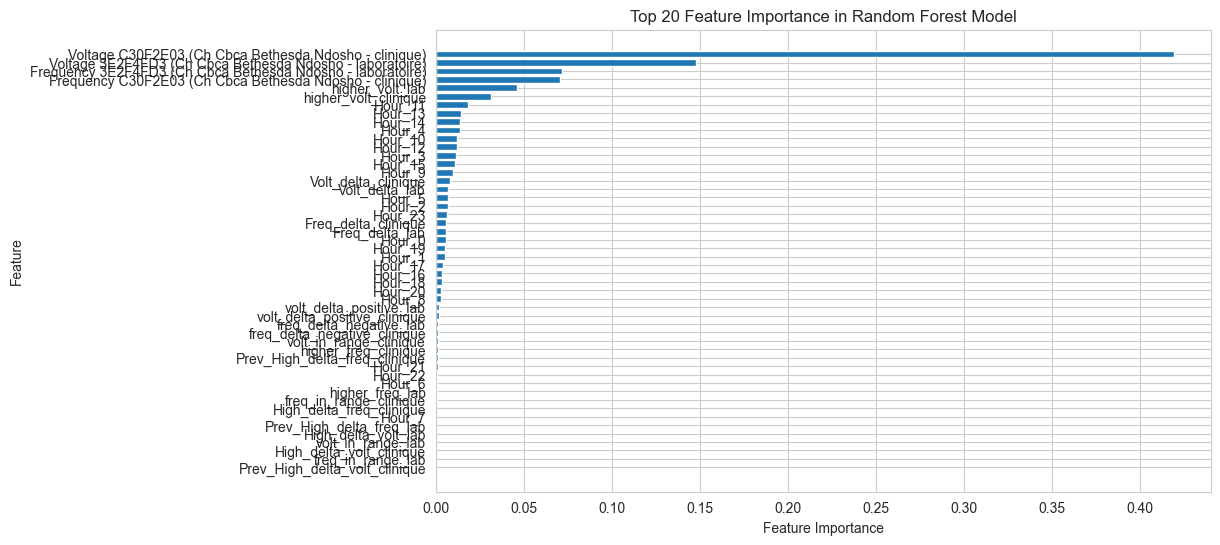

In [58]:
# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

In [59]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[23211     0]
 [    0  4005]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    23211
True      4005
Name: count, dtype: int64


In [60]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9937169312169312
Confusion Matrix:
[[14814    10]
 [  104  3216]]
Precision: 0.9969001859888407
Recall: 0.9686746987951808
Test data prediction distribution:
prediction
False    14918
True      3226
Name: count, dtype: int64


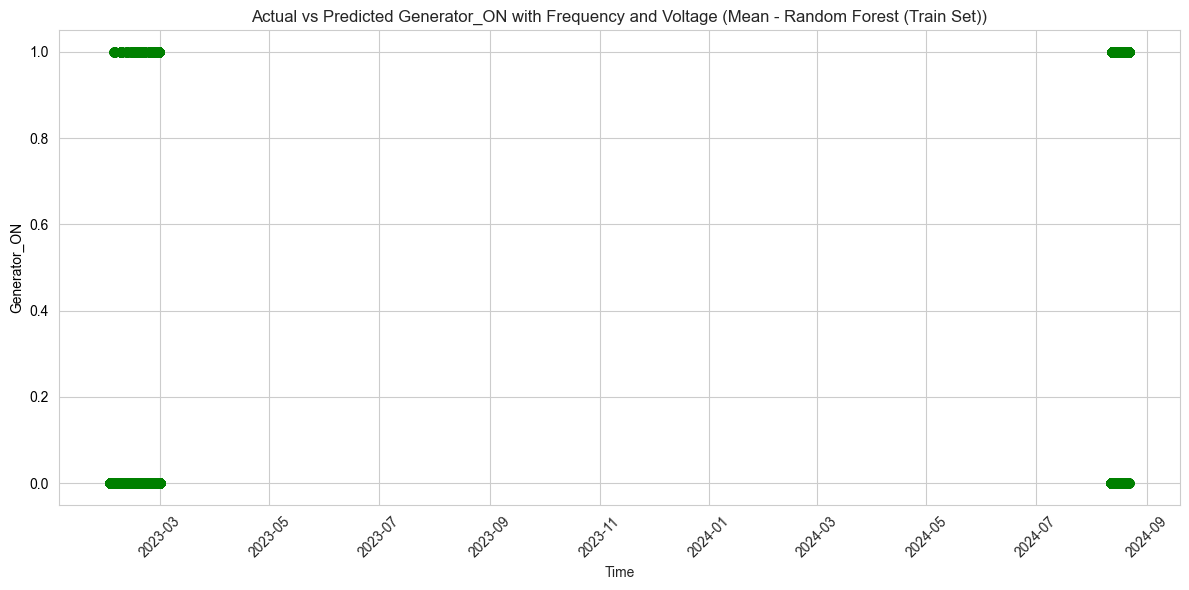

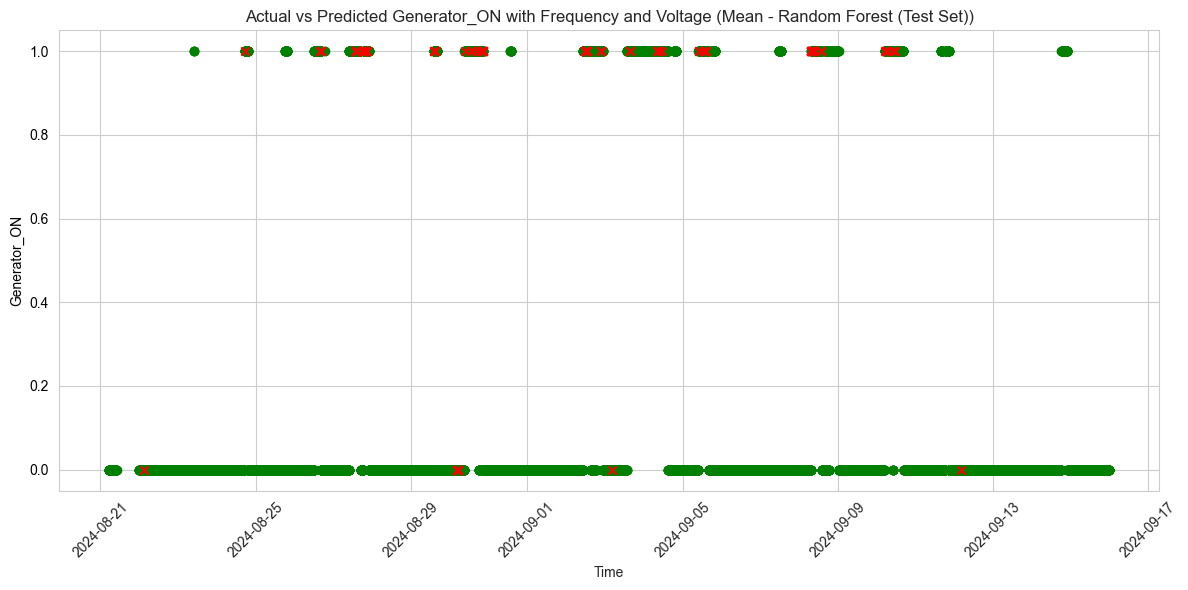

In [61]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=False, include_frequency=False)

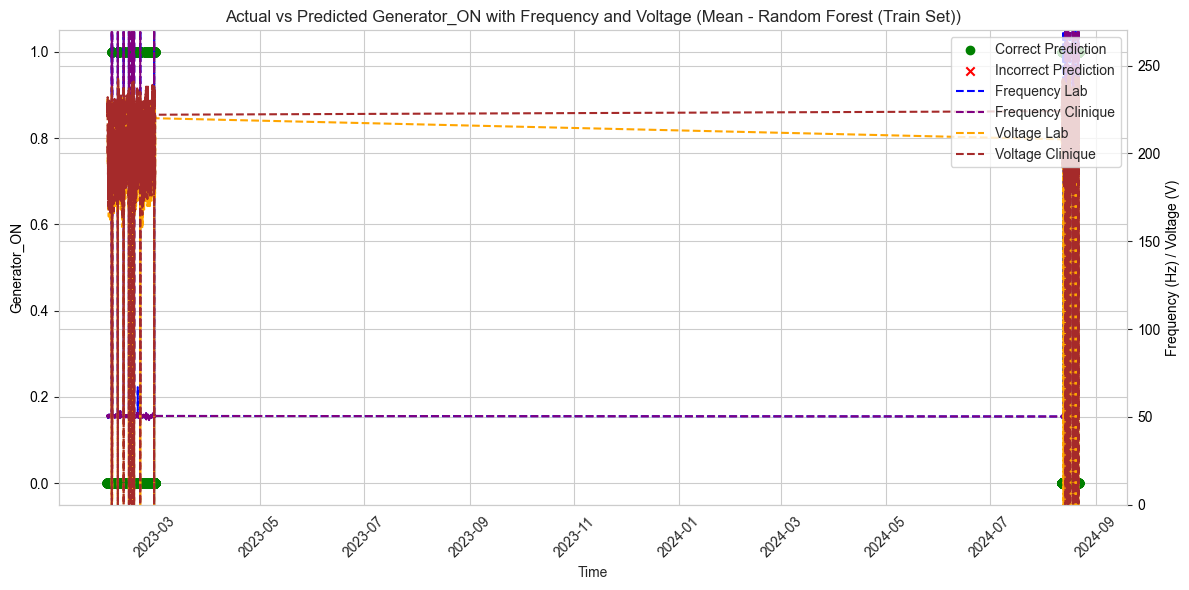

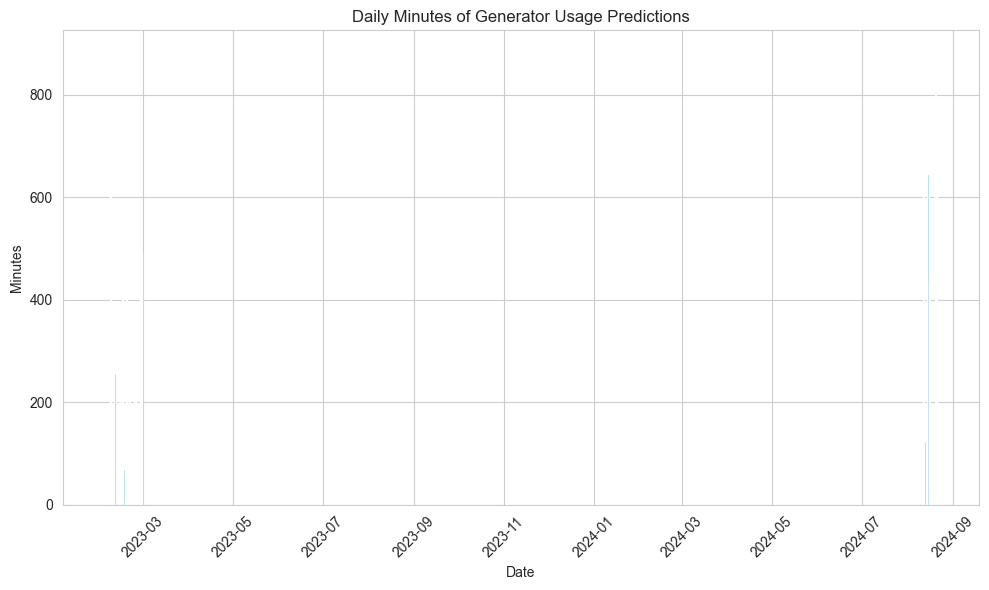

,Date,Count,Minutes,Hours
0,2023-02-03,75,150,2.500000
1,2023-02-07,352,704,11.733333
2,2023-02-10,129,258,4.300000
3,2023-02-13,145,290,4.833333
4,2023-02-15,210,420,7.000000
5,2023-02-16,35,70,1.166667
6,2023-02-18,221,442,7.366667
7,2023-02-20,194,388,6.466667
8,2023-02-23,191,382,6.366667
9,2023-02-24,197,394,6.566667


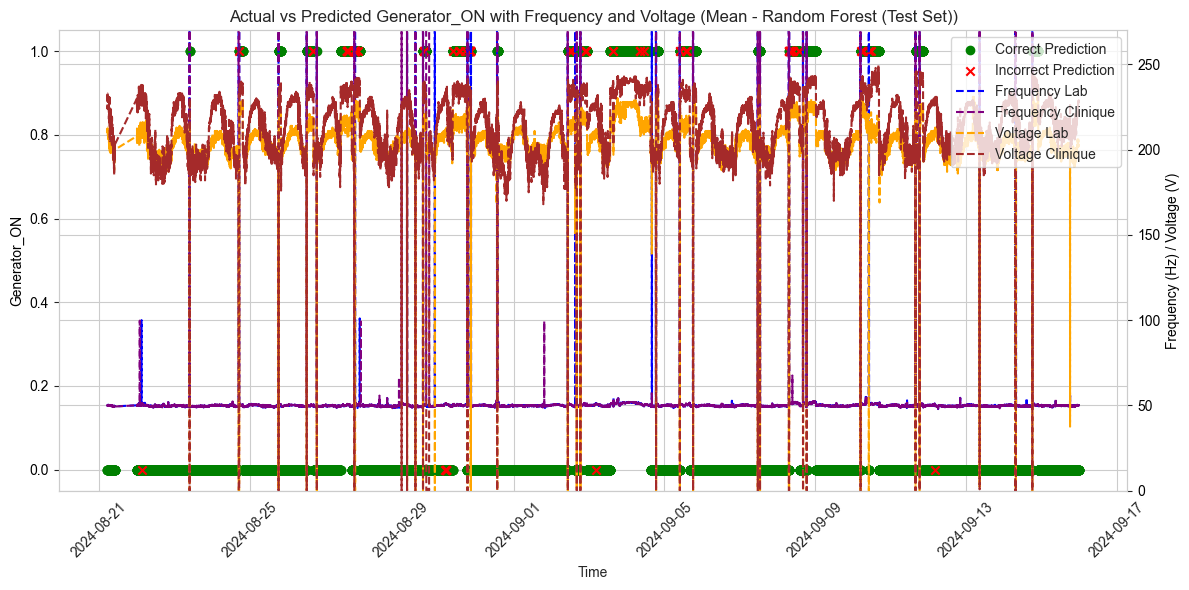

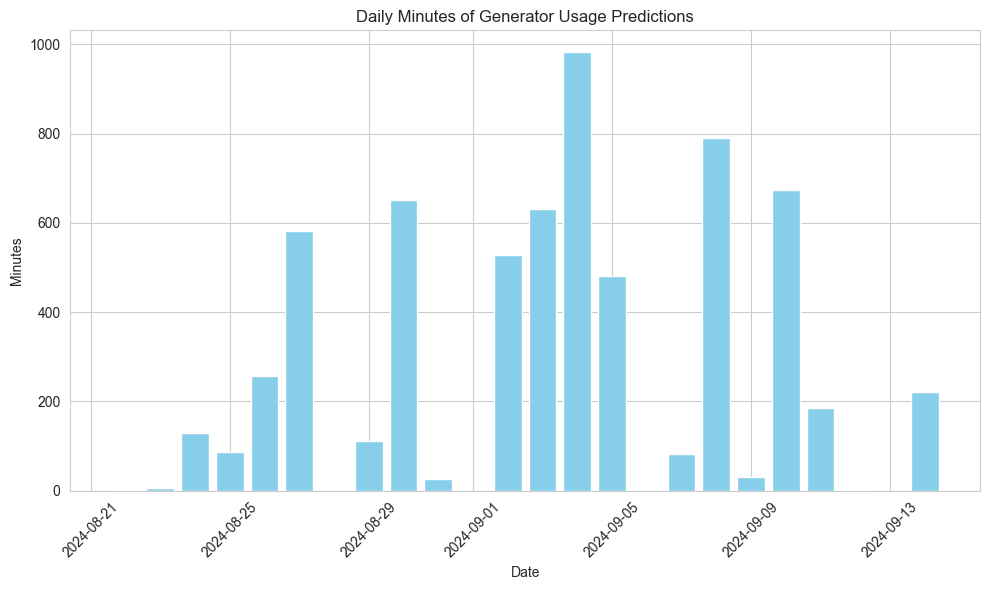

,Date,Count,Minutes,Hours
0,2024-08-22,1,2,0.033333
1,2024-08-23,3,6,0.100000
2,2024-08-24,65,130,2.166667
3,2024-08-25,43,86,1.433333
4,2024-08-26,128,256,4.266667
5,2024-08-27,291,582,9.700000
6,2024-08-29,56,112,1.866667
7,2024-08-30,325,650,10.833333
8,2024-08-31,13,26,0.433333
9,2024-09-02,264,528,8.800000


In [62]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=True, include_frequency=True)
train_data_ts_rf_daily_count = plot_true_predictions_histogram(train_data_ts_rf)
display(train_data_ts_rf_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=True, include_frequency=True)
test_data_ts_rf_daily_count = plot_true_predictions_histogram(test_data_ts_rf)
display(test_data_ts_rf_daily_count)

In [63]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_rf)
display_generator_statistics(test_data_ts_rf)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Actual Minutes: 3320 minutes, or 55.33 hours within 302.40 hours
Predicted Minutes: 3226 minutes, or 53.77 hours within 302.40 hours


#### 4.2.3. Using Mean of Voltage and Frequency as a Threshold and Time Series - XGBoost

In [64]:

# Step 0: Copy rf data
train_data_ts_boost = train_data_ts.copy()
test_data_ts_boost = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_boost, test_data_ts_boost = calculate_mean_flags(
    train_data_ts_boost,
    test_data_ts_boost,
    train_data_base,
    columns_to_compare
)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Step 1: Prepare training and testing sets
X_train = train_data_ts_boost[feature_columns].copy()
y_train = train_data_ts_boost['Generator_ON']

X_test = test_data_ts_boost[feature_columns].copy()
y_test = test_data_ts_boost['Generator_ON']

# Ensure all columns are numeric
for col in ['Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
            'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique']:
    X_train.loc[:, col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test.loc[:, col] = pd.to_numeric(X_test[col], errors='coerce')

# Optional: Handle missing values if present
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

'''
# Step 2: Train an XGBoost Classifier with GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

# Fit the model
grid_search.fit(X_train, y_train)

# Output best parameters
print("Best parameters:", grid_search.best_params_)
'''

/var/folders/7q/629hmk5n2d38m2bbwtv3djvc0000gn/T/ipykernel_37092/381545247.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train.fillna(0, inplace=True)
/var/folders/7q/629hmk5n2d38m2bbwtv3djvc0000gn/T/ipykernel_37092/381545247.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test.fillna(0, inplace=True)


'\n# Step 2: Train an XGBoost Classifier with GridSearchCV\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\n# Initialize GridSearchCV\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42, eval_metric=\'logloss\'),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\n# Fit the model\ngrid_search.fit(X_train, y_train)\n\n# Output best parameters\nprint("Best parameters:", grid_search.best_params_)\n'

In [65]:
''''
# Step 3: Make Predictions on the train and test sets
train_data_ts_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\'\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nfeature_importance_df = pd.DataFrame({\n    \'Feature\': feature_columns,\n    \'Importance\': importances\n})\n\n# Sort the features by importance and keep only the top 20\ntop_20_features = feature_importance_df.sort_values(by=\'Importance\', ascending=False).head(20)\n\n# Display the top 20 most important features\nprint("Top 20 features sorted by importance (XGBoost):")\ndisplay(top_20_features)\n\n# Visualize the top 20 feature importances\nplt.figure(figsize=(10, 6))\nplt.barh(top_20_features[\'Feature\'], top_20_features[\'Importance\'])\nplt.xlabel(\'Feature Importance\')\nplt.ylabel(\'Feature\')\nplt.title(\'Top 20 Feature Importance in XGBoost Model\')\nplt.gca

In [66]:
# Use the best parameters from GridSearchCV
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}

# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_boost['prediction'] = final_model.predict(X_train)
test_data_ts_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_boost['prediction']))

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00     14824
        True       0.99      0.97      0.98      3320

    accuracy                           0.99     18144
   macro avg       0.99      0.98      0.99     18144
weighted avg       0.99      0.99      0.99     18144

AUC-ROC Score:
0.9993590355756539
Confusion Matrix:
[[14800    24]
 [  109  3211]]


In [67]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9966931216931217
Confusion Matrix:
[[23143    68]
 [   22  3983]]
Precision: 0.9832140212293261
Recall: 0.9945068664169788
Train data prediction distribution (XGBoost):
prediction
0    23165
1     4051
Name: count, dtype: int64


In [68]:
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_boost['prediction'].value_counts())


Test Set Evaluation (XGBoost):
Accuracy: 0.9926697530864198
Confusion Matrix:
[[14800    24]
 [  109  3211]]
Precision: 0.99258114374034
Recall: 0.9671686746987952
Test data prediction distribution (XGBoost):
prediction
0    14909
1     3235
Name: count, dtype: int64


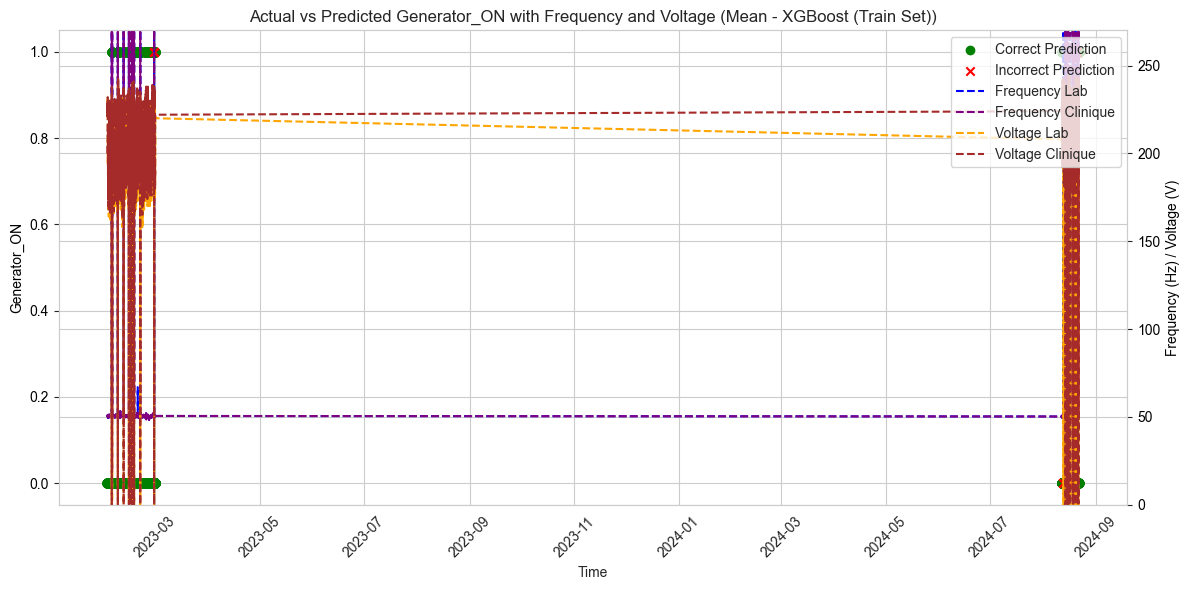

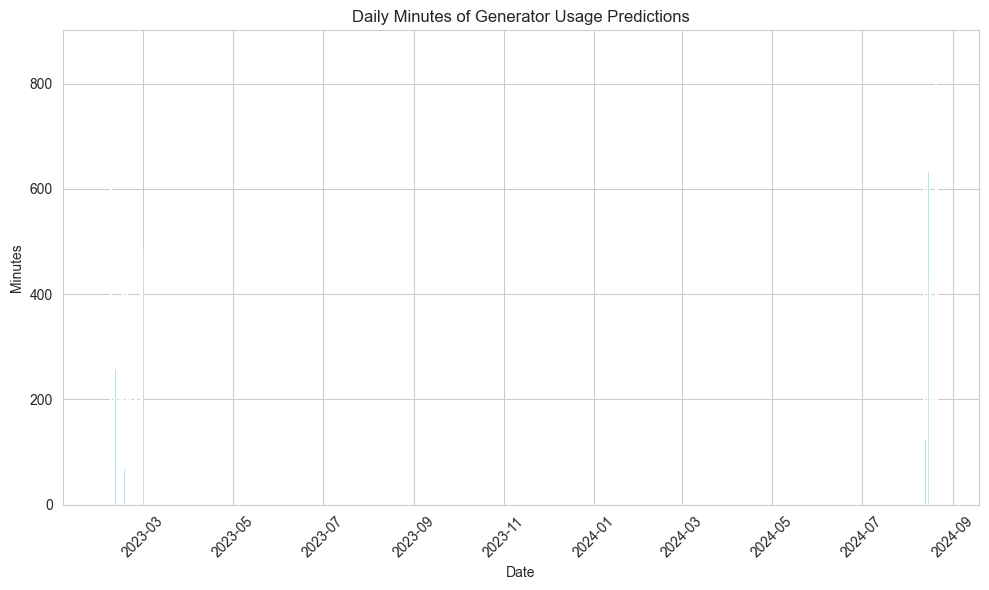

,Date,Count,Minutes,Hours
0,2023-02-03,75,150,2.500000
1,2023-02-07,352,704,11.733333
2,2023-02-10,129,258,4.300000
3,2023-02-13,145,290,4.833333
4,2023-02-15,210,420,7.000000
5,2023-02-16,35,70,1.166667
6,2023-02-18,221,442,7.366667
7,2023-02-20,194,388,6.466667
8,2023-02-23,191,382,6.366667
9,2023-02-24,197,394,6.566667


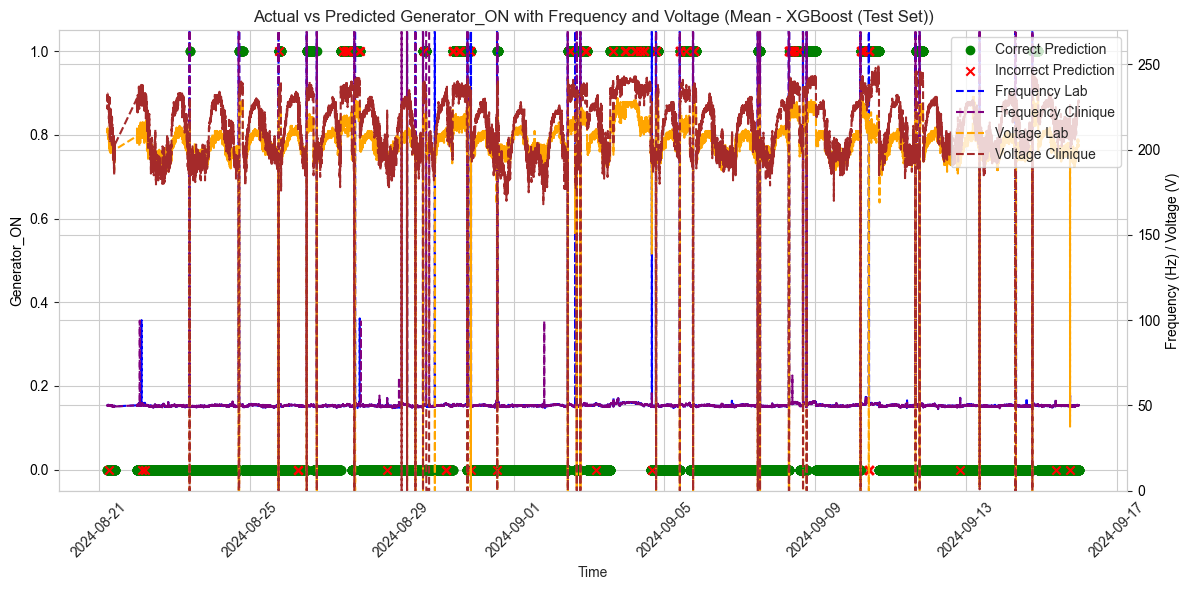

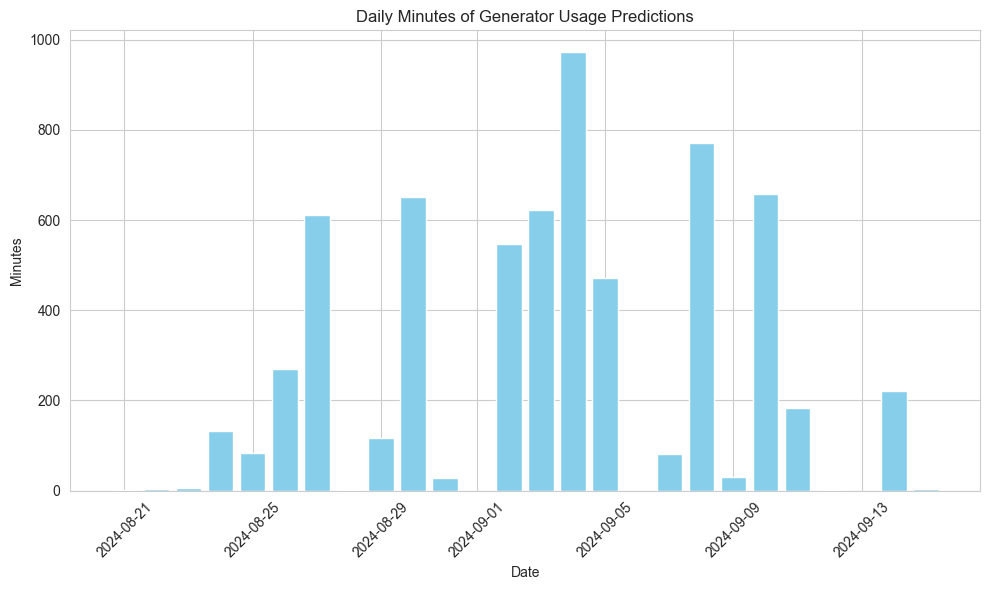

,Date,Count,Minutes,Hours
0,2024-08-21,1,2,0.033333
1,2024-08-22,2,4,0.066667
2,2024-08-23,3,6,0.100000
3,2024-08-24,66,132,2.200000
4,2024-08-25,42,84,1.400000
5,2024-08-26,135,270,4.500000
6,2024-08-27,306,612,10.200000
7,2024-08-28,1,2,0.033333
8,2024-08-29,58,116,1.933333
9,2024-08-30,326,652,10.866667


In [69]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_boost, model_name="Mean - XGBoost (Train Set)", include_voltage=True, include_frequency=True)
train_data_ts_boost_daily_count = plot_true_predictions_histogram(train_data_ts_boost)
display(train_data_ts_boost_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_boost, model_name="Mean - XGBoost (Test Set)", include_voltage=True, include_frequency=True)
test_data_ts_boost_daily_count = plot_true_predictions_histogram(test_data_ts_boost)
display(test_data_ts_boost_daily_count)

In [70]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_boost)
display_generator_statistics(test_data_ts_boost)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4051 minutes, or 67.52 hours within 453.60 hours
Actual Minutes: 3320 minutes, or 55.33 hours within 302.40 hours
Predicted Minutes: 3235 minutes, or 53.92 hours within 302.40 hours


## 5. Applying the Model with Other Data

#### 5.1. Using 1 Month Data and Check the Prediction Result

In [71]:
# Opening files
file_list = ['Voltage Time Series-data-2024-10-25 13_13_06.csv',  
             'Voltage Time Series-data-2024-10-25 13_13_40.csv', 
             'Voltage Time Series-data-2024-10-25 13_14_12.csv',
             'Voltage Time Series-data-2024-10-25 13_14_37.csv',
             'Voltage Time Series-data-2024-10-25 13_18_07.csv']

# Initialize an empty list to collect DataFrames
data_frames_2 = []

file_path_2 = '../data/ChCbNdosho/1_Month_Data/'

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path_2 + file)
    data_frames_2.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames_2, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)
0,2024-09-10 00:00:00,50.1,50.0,207.0,223.0
1,2024-09-10 00:02:00,49.8,49.8,203.0,221.0
2,2024-09-10 00:04:00,49.7,49.7,202.0,221.0
3,2024-09-10 00:06:00,49.8,49.8,204.0,221.0
4,2024-09-10 00:08:00,49.9,50.0,204.0,222.0
...,...,...,...,...,...
25195,2024-10-14 23:50:00,50.1,50.0,210.0,206.0
25196,2024-10-14 23:52:00,49.6,49.6,209.0,205.0
25197,2024-10-14 23:54:00,49.8,49.8,209.0,207.0
25198,2024-10-14 23:56:00,49.9,49.9,210.0,208.0


In [72]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2, test_data_2_dummy = calculate_mean_flags(data, data, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2, test_data_2_dummy = process_time_series_data(test_data_2, test_data_2, high_freq_threshold,
                                                       low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

Processed data after feature generation: 


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,Freq_delta_lab,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2024-09-10 00:00:00,50.1,50.0,207.0,223.0,False,False,True,True,NaN,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2024-09-10 00:02:00,49.8,49.8,203.0,221.0,False,False,False,True,-0.3,...,False,False,False,False,False,False,False,False,False,False
2,2024-09-10 00:04:00,49.7,49.7,202.0,221.0,False,False,False,True,-0.1,...,False,False,False,False,False,False,False,False,False,False
3,2024-09-10 00:06:00,49.8,49.8,204.0,221.0,False,False,False,True,0.1,...,False,False,False,False,False,False,False,False,False,False
4,2024-09-10 00:08:00,49.9,50.0,204.0,222.0,False,False,False,True,0.1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,2024-10-14 23:50:00,50.1,50.0,210.0,206.0,False,False,True,False,0.1,...,False,True,False,False,False,False,False,False,False,False
25196,2024-10-14 23:52:00,49.6,49.6,209.0,205.0,False,False,True,False,-0.5,...,False,True,False,False,False,False,False,False,False,False
25197,2024-10-14 23:54:00,49.8,49.8,209.0,207.0,False,False,True,False,0.2,...,False,True,False,False,False,False,False,False,False,False
25198,2024-10-14 23:56:00,49.9,49.9,210.0,208.0,False,False,True,False,0.1,...,False,True,False,False,False,False,False,False,False,False


##### PREDICTION RESULT #####
Predicted Minutes: 18686 minutes, or 311.43 hours within 840.00 hours


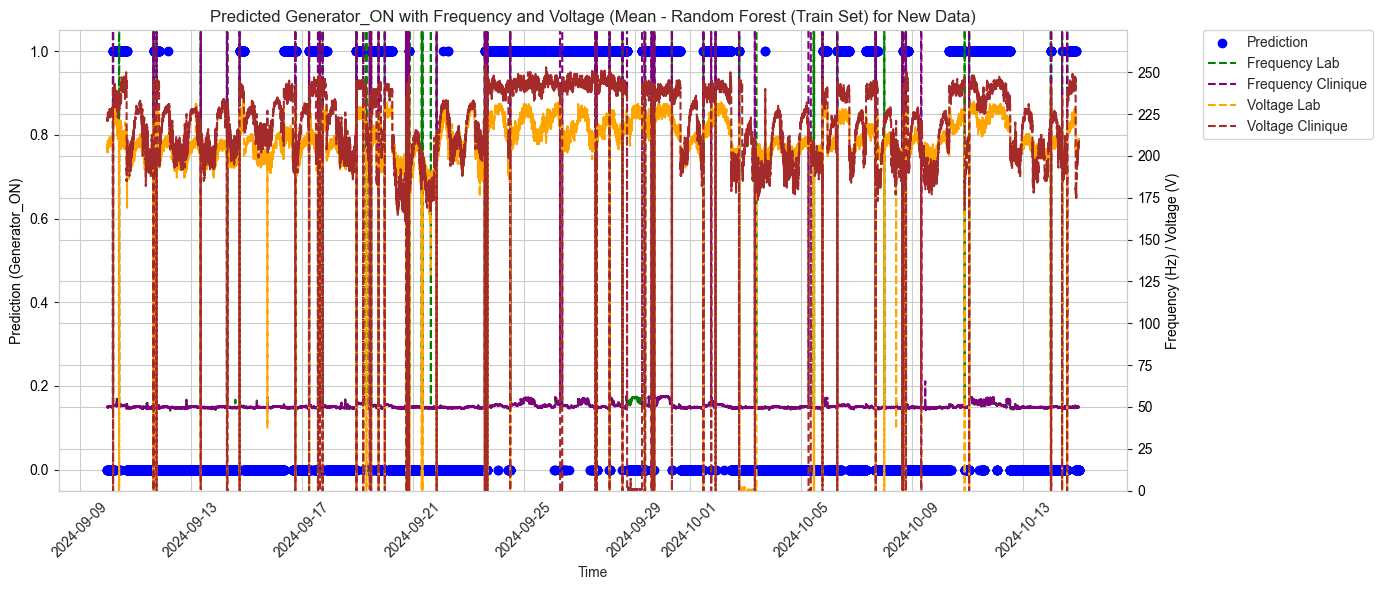

In [73]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

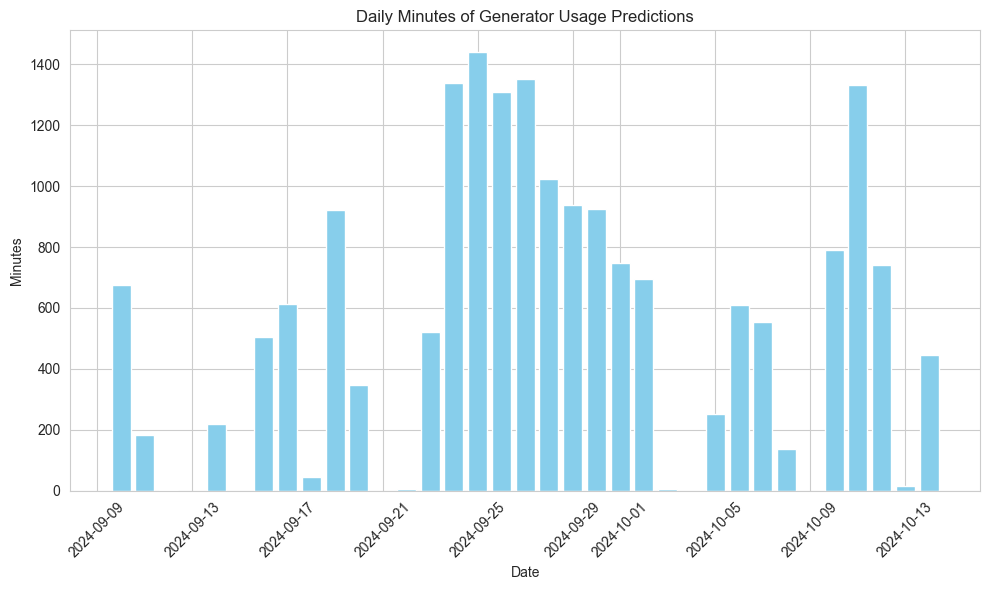

,Date,Count,Minutes,Hours
0,2024-09-10,337,674,11.233333
1,2024-09-11,92,184,3.066667
2,2024-09-12,1,2,0.033333
3,2024-09-14,110,220,3.666667
4,2024-09-16,252,504,8.400000
5,2024-09-17,307,614,10.233333
6,2024-09-18,22,44,0.733333
7,2024-09-19,461,922,15.366667
8,2024-09-20,173,346,5.766667
9,2024-09-22,3,6,0.100000


In [74]:
test_data_2_daily_count = plot_true_predictions_histogram(test_data_2)
test_data_2_daily_count

#### 5.2. Using 1 Year Data of Year 2023

Loading 1 year data into 1 dataframe:

In [75]:
# Set the path to the folder containing CSV files
folder_path = '../data/ChCbNdosho/2023 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2023 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2023['time'] = pd.to_datetime(data_2023['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2023 = data_2023.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2023

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time
0,2023-01-01 00:00:00,50.3,50.3,198.0,199.0,2023-01-01 00:00:00
1,2023-01-01 00:02:00,50.2,50.2,200.0,202.0,2023-01-01 00:02:00
2,2023-01-01 00:04:00,50.0,50.0,202.0,204.0,2023-01-01 00:04:00
3,2023-01-01 00:06:00,50.3,50.3,203.0,204.0,2023-01-01 00:06:00
4,2023-01-01 00:08:00,50.1,50.1,202.0,204.0,2023-01-01 00:08:00
...,...,...,...,...,...,...
267835,2023-12-31 23:50:00,49.9,49.9,202.0,209.0,2023-12-31 23:50:00
267836,2023-12-31 23:52:00,49.9,49.8,202.0,209.0,2023-12-31 23:52:00
267837,2023-12-31 23:54:00,50.0,50.0,202.0,210.0,2023-12-31 23:54:00
267838,2023-12-31 23:56:00,50.1,50.1,202.0,210.0,2023-12-31 23:56:00


In [76]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2023, test_data_2023_dummy = calculate_mean_flags(data_2023, data_2023, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2023, test_data_2023_dummy = process_time_series_data(test_data_2023, test_data_2023, high_freq_threshold,
                                                       low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2023)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2023[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2023['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

Processed data after feature generation: 


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2023-01-01 00:00:00,50.3,50.3,198.0,199.0,2023-01-01 00:00:00,False,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2023-01-01 00:02:00,50.2,50.2,200.0,202.0,2023-01-01 00:02:00,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-01 00:04:00,50.0,50.0,202.0,204.0,2023-01-01 00:04:00,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-01 00:06:00,50.3,50.3,203.0,204.0,2023-01-01 00:06:00,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 00:08:00,50.1,50.1,202.0,204.0,2023-01-01 00:08:00,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267835,2023-12-31 23:50:00,49.9,49.9,202.0,209.0,2023-12-31 23:50:00,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
267836,2023-12-31 23:52:00,49.9,49.8,202.0,209.0,2023-12-31 23:52:00,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
267837,2023-12-31 23:54:00,50.0,50.0,202.0,210.0,2023-12-31 23:54:00,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
267838,2023-12-31 23:56:00,50.1,50.1,202.0,210.0,2023-12-31 23:56:00,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False


##### PREDICTION RESULT #####
Predicted Minutes: 113200 minutes, or 1886.67 hours within 8928.00 hours


##### 5.2.1. Plot Result During Lost Clinique Data (2023)

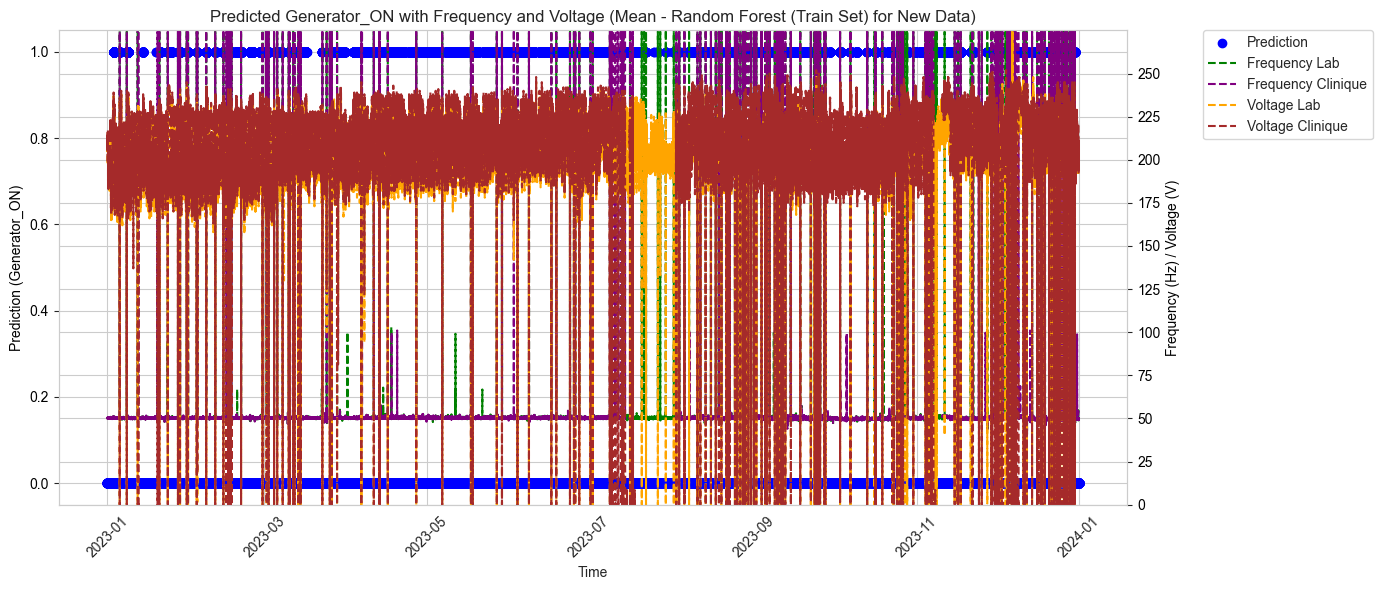

In [77]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2023, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:475: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


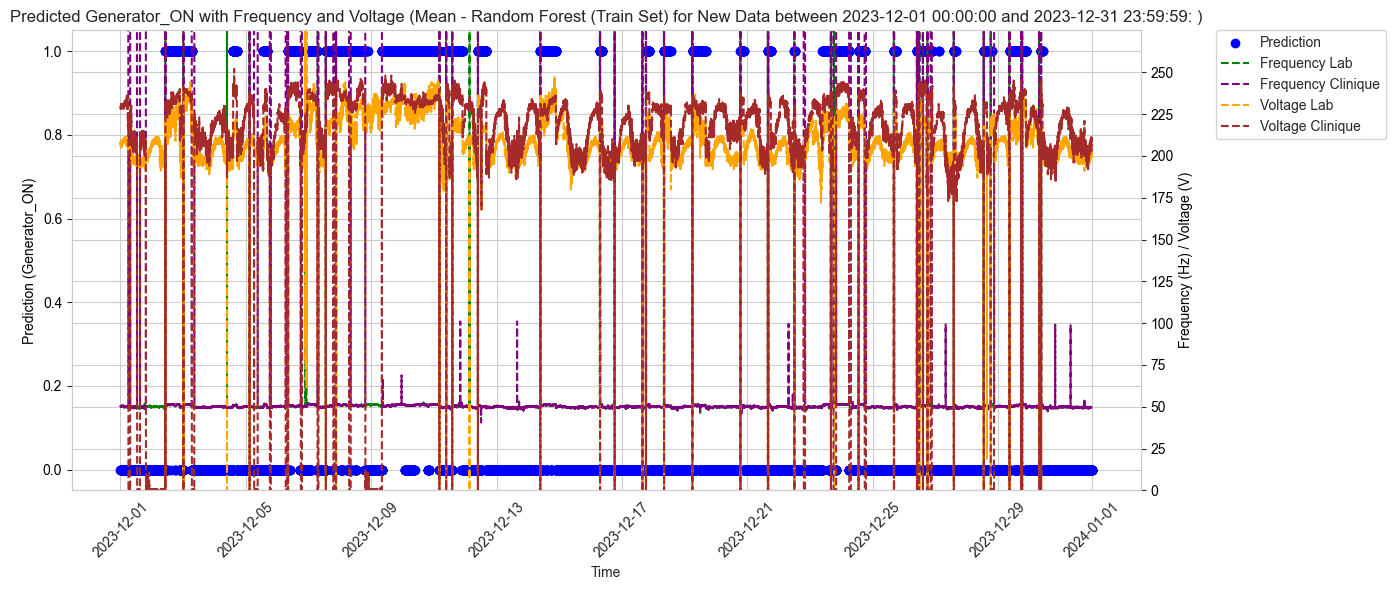

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


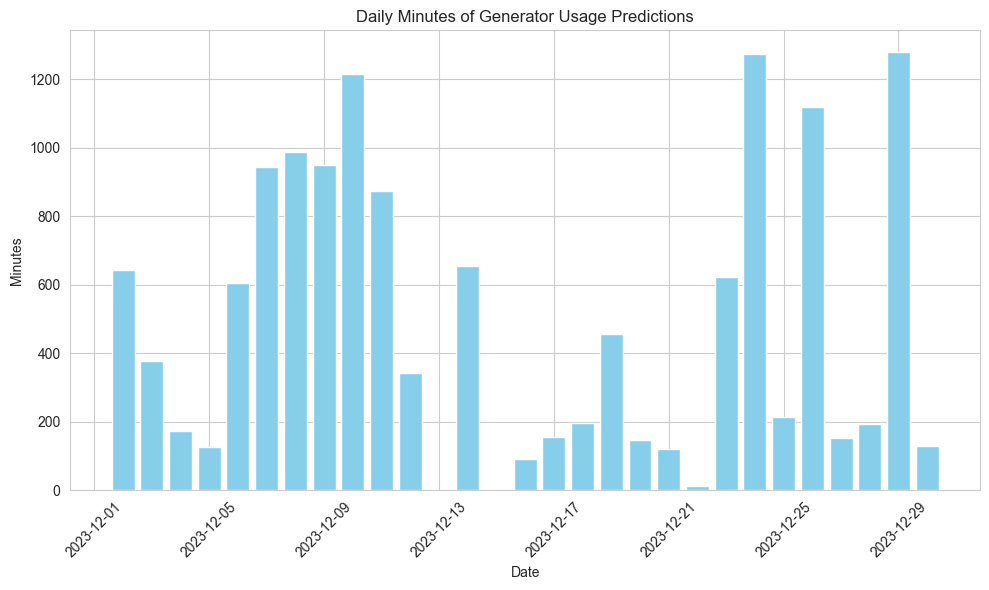

,Date,Count,Minutes,Hours
0,2023-12-02,321,642,10.700000
1,2023-12-03,189,378,6.300000
2,2023-12-04,86,172,2.866667
3,2023-12-05,63,126,2.100000
4,2023-12-06,303,606,10.100000
5,2023-12-07,472,944,15.733333
6,2023-12-08,494,988,16.466667
7,2023-12-09,474,948,15.800000
8,2023-12-10,608,1216,20.266667
9,2023-12-11,437,874,14.566667


##### PREDICTION RESULT #####
Predicted Minutes: 14056 minutes, or 234.27 hours within 912.00 hours
Average Daily Usage Minutes: 520.5925925925926 minutes, or 8.676543209876543 hours
Max minutes of usage 1278 minutes or 21.3 hours. Date: 2023-12-29


In [78]:
# Plot predictions based on certain timing choosen

start_date = '2023-12-01 00:00:00'
finished_date = '2023-12-31 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30
average_daily = filtered_test_data_2_daily_count['Minutes'].sum() / filtered_test_data_2_daily_count.shape[0] 
max_daily = filtered_test_data_2_daily_count['Minutes'].max()
# Find the row with the maximum 'Minutes' value
max_daily_row = filtered_test_data_2_daily_count.loc[filtered_test_data_2_daily_count['Minutes'].idxmax()]
# Extract the 'Date' column from that row
max_date = max_daily_row['Date']


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')
print(f'Average Daily Usage Minutes: {average_daily} minutes, or {average_daily / 60} hours')
print(f'Max minutes of usage {max_daily} minutes or {max_daily / 60} hours. Date: {max_date}')

##### 5.2.2. Plot Result First 10 days of July (2023)

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:475: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


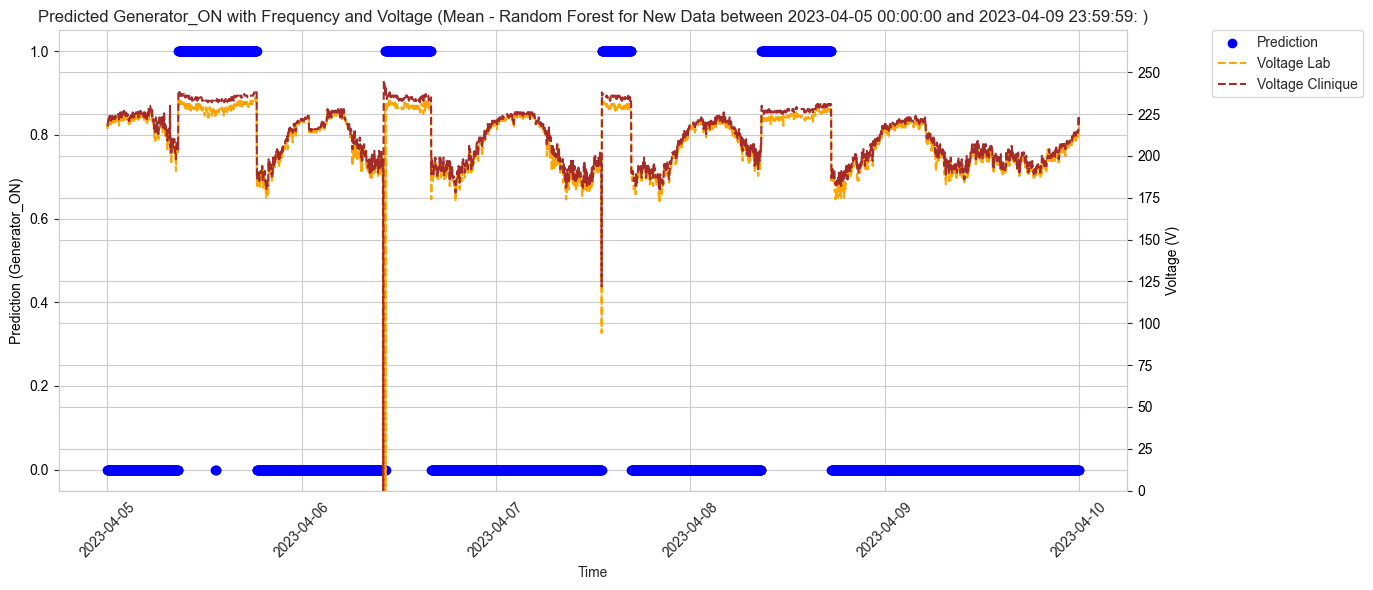

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:475: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


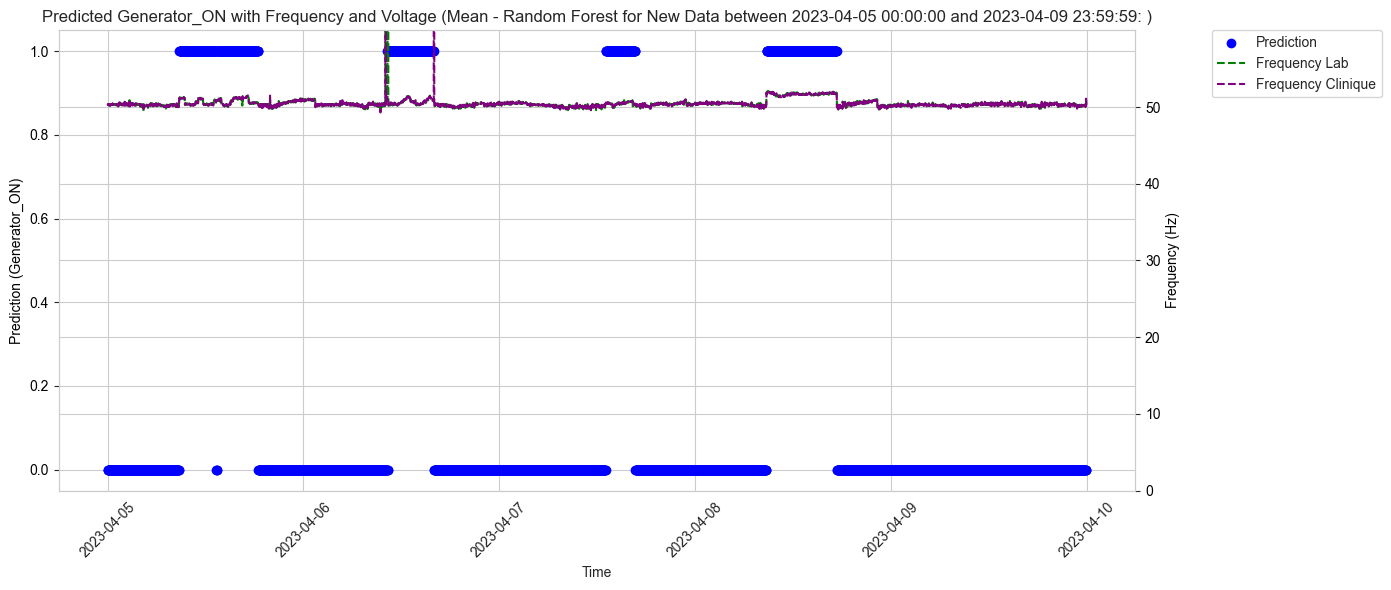

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


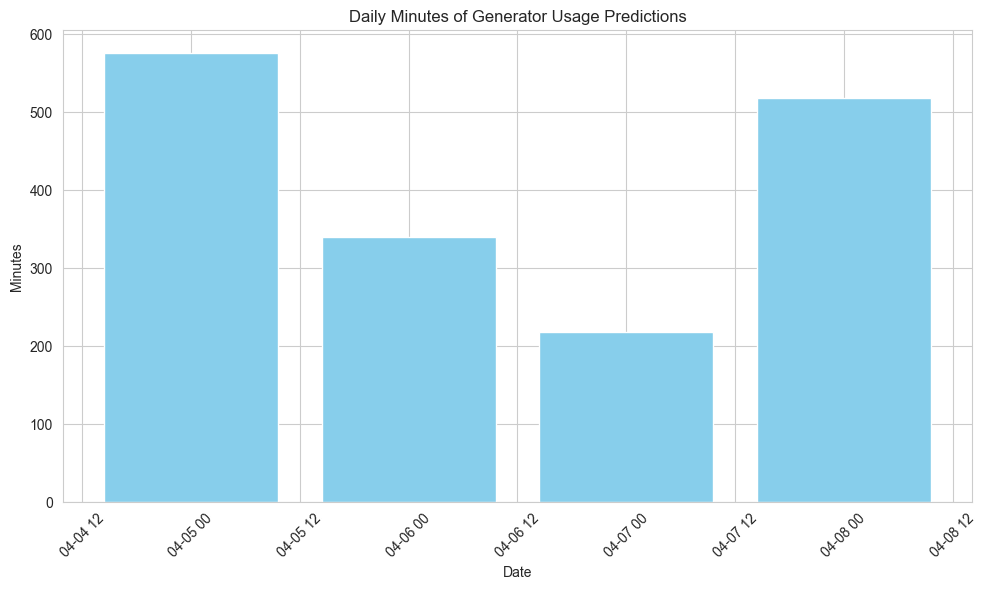

,Date,Count,Minutes,Hours
0,2023-04-05,288,576,9.600000
1,2023-04-06,170,340,5.666667
2,2023-04-07,109,218,3.633333
3,2023-04-08,259,518,8.633333


##### PREDICTION RESULT #####
Predicted Minutes: 1652 minutes, or 27.53 hours within 120.00 hours


In [79]:
# Plot predictions based on certain timing choosen
start_date = '2023-04-05 00:00:00'
finished_date = '2023-04-09 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=False
)

# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=False,
    include_frequency=True
)

# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

#### 5.3. Using Data of Year 2022

Due to data limitations, only Data from 27th May 2022 - 31st December 2022 is available

In [80]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = '../data/ChCbNdosho/2022 Data'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2022 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2022['time'] = pd.to_datetime(data_2022['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2022 = data_2022.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2022


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time
0,2022-05-28 00:00:00,50.6,50.7,226.0,226.0,2022-05-28 00:00:00
1,2022-05-28 00:02:00,50.6,50.6,226.0,226.0,2022-05-28 00:02:00
2,2022-05-28 00:04:00,50.3,50.3,226.0,226.0,2022-05-28 00:04:00
3,2022-05-28 00:06:00,50.1,50.1,228.0,228.0,2022-05-28 00:06:00
4,2022-05-28 00:08:00,50.1,50.2,226.0,226.0,2022-05-28 00:08:00
...,...,...,...,...,...,...
156954,2022-12-31 23:50:00,50.0,50.0,198.0,199.0,2022-12-31 23:50:00
156955,2022-12-31 23:52:00,50.1,50.1,198.0,199.0,2022-12-31 23:52:00
156956,2022-12-31 23:54:00,50.1,50.1,199.0,200.0,2022-12-31 23:54:00
156957,2022-12-31 23:56:00,50.0,50.0,199.0,201.0,2022-12-31 23:56:00


In [81]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2022, test_data_2022_dummy = calculate_mean_flags(data_2022, data_2022, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2022, test_data_2022_dummy = process_time_series_data(test_data_2022, test_data_2022, high_freq_threshold,
                                                       low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2022)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2022[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2022['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2022['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2022) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

Processed data after feature generation: 


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2022-05-28 00:00:00,50.6,50.7,226.0,226.0,2022-05-28 00:00:00,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2022-05-28 00:02:00,50.6,50.6,226.0,226.0,2022-05-28 00:02:00,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2022-05-28 00:04:00,50.3,50.3,226.0,226.0,2022-05-28 00:04:00,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2022-05-28 00:06:00,50.1,50.1,228.0,228.0,2022-05-28 00:06:00,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2022-05-28 00:08:00,50.1,50.2,226.0,226.0,2022-05-28 00:08:00,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156954,2022-12-31 23:50:00,50.0,50.0,198.0,199.0,2022-12-31 23:50:00,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
156955,2022-12-31 23:52:00,50.1,50.1,198.0,199.0,2022-12-31 23:52:00,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
156956,2022-12-31 23:54:00,50.1,50.1,199.0,200.0,2022-12-31 23:54:00,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
156957,2022-12-31 23:56:00,50.0,50.0,199.0,201.0,2022-12-31 23:56:00,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


##### PREDICTION RESULT #####
Predicted Minutes: 28878 minutes, or 481.30 hours within 5231.97 hours


##### 5.2.2. Plot Result During Lost Clinique Data (2022)

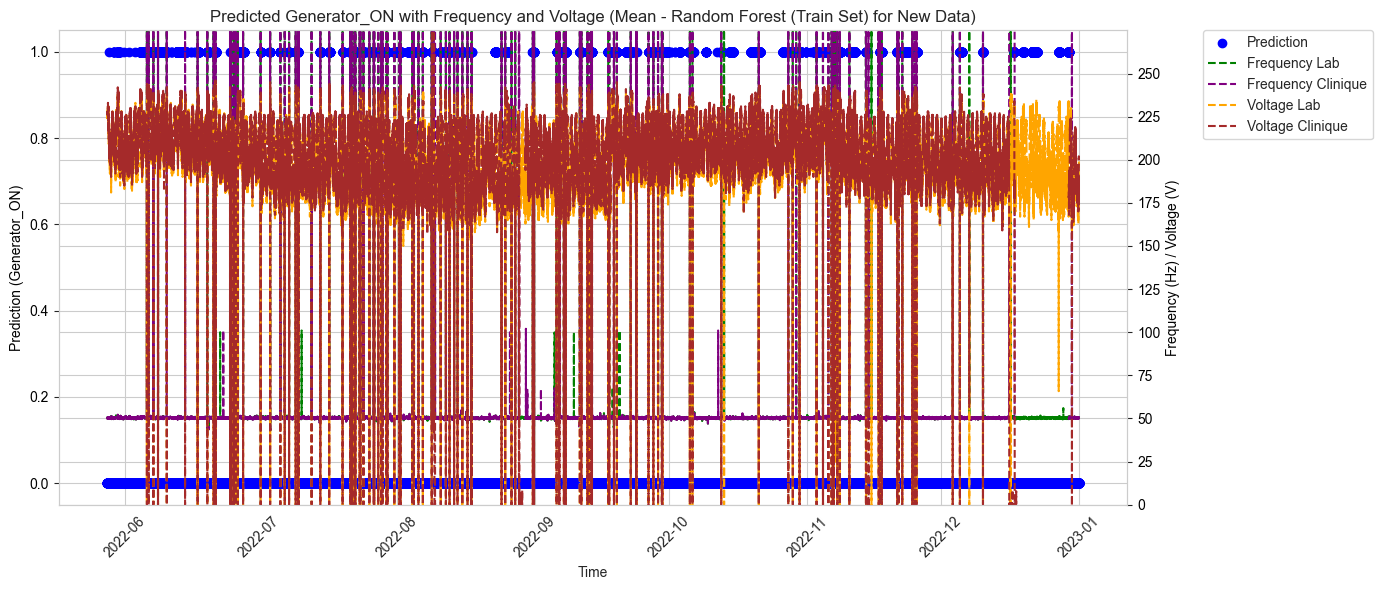

In [82]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2022, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:475: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


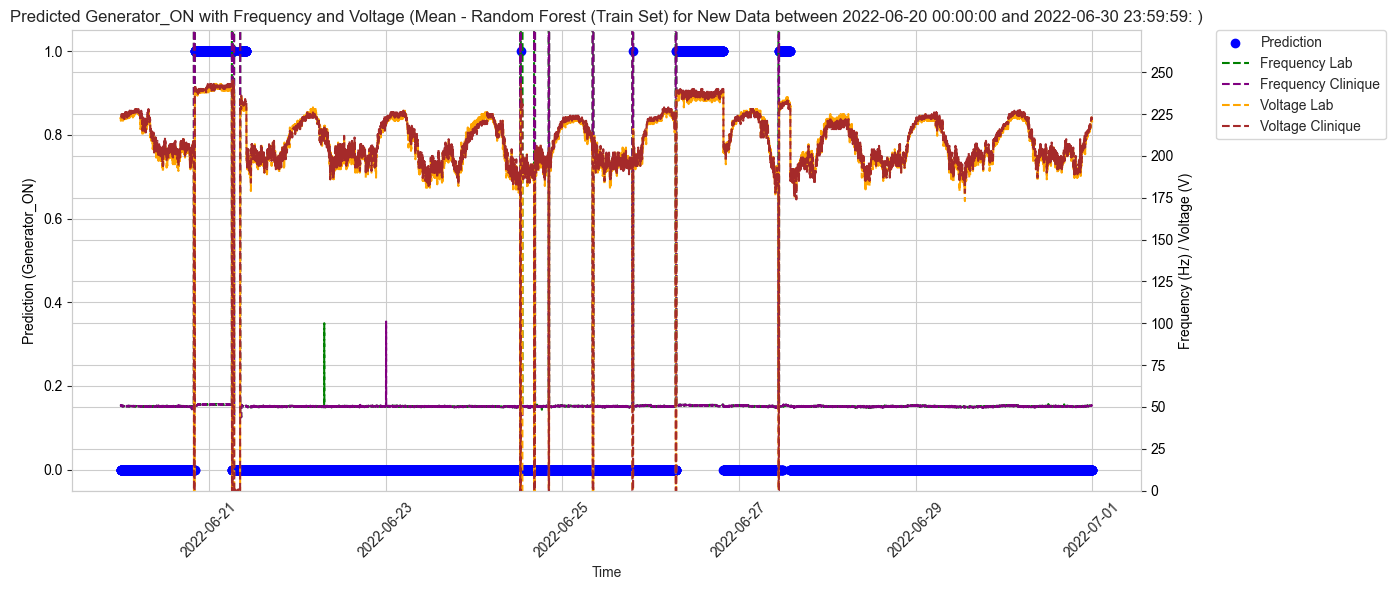

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


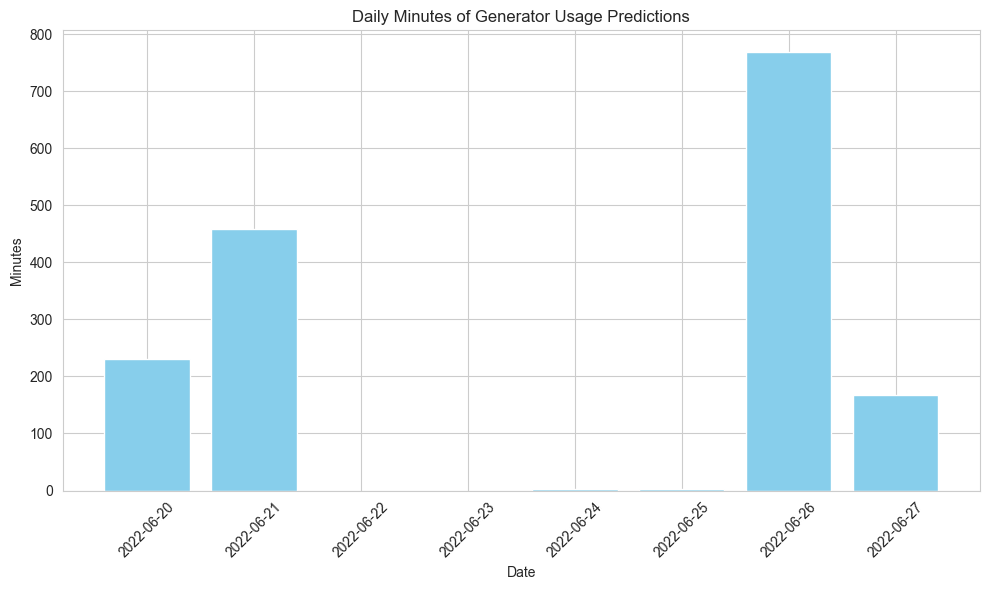

,Date,Count,Minutes,Hours
0,2022-06-20,115,230,3.833333
1,2022-06-21,229,458,7.633333
2,2022-06-24,1,2,0.033333
3,2022-06-25,1,2,0.033333
4,2022-06-26,384,768,12.800000
5,2022-06-27,84,168,2.800000


##### PREDICTION RESULT #####
Predicted Minutes: 1628 minutes, or 27.13 hours within 264.00 hours


In [83]:
# Plot predictions based on certain timing choosen

start_date = '2022-06-20 00:00:00'
finished_date = '2022-06-30 23:59:59'
filtered_test_data_2022 = test_data_2022[(test_data_2022['Time'] >= start_date) & (test_data_2022['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2022,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2022)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2022['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2022) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

#### 5.4. Using Data of Year 2024

In [84]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = '../data/ChCbNdosho/2024 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2024 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2024['time'] = pd.to_datetime(data_2024['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2024 = data_2024.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2024

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time
0,2024-01-01 00:00:00,50.1,50.1,201.0,211.0,2024-01-01 00:00:00
1,2024-01-01 00:02:00,49.7,49.7,202.0,210.0,2024-01-01 00:02:00
2,2024-01-01 00:04:00,49.8,49.8,202.0,210.0,2024-01-01 00:04:00
3,2024-01-01 00:06:00,49.9,49.9,201.0,213.0,2024-01-01 00:06:00
4,2024-01-01 00:08:00,50.0,50.0,204.0,209.0,2024-01-01 00:08:00
...,...,...,...,...,...,...
226766,2024-11-10 23:50:00,50.1,50.1,230.0,222.0,2024-11-10 23:50:00
226767,2024-11-10 23:52:00,50.0,50.2,230.0,222.0,2024-11-10 23:52:00
226768,2024-11-10 23:54:00,50.2,50.1,230.0,222.0,2024-11-10 23:54:00
226769,2024-11-10 23:56:00,49.9,50.2,231.0,223.0,2024-11-10 23:56:00


In [85]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2024, test_data_2024_dummy = calculate_mean_flags(data_2024, data_2024, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2024, test_data_2024_dummy = process_time_series_data(test_data_2024, test_data_2024, high_freq_threshold,
                                                       low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2024)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2024[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2024['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2024['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2024) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

Processed data after feature generation: 


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2024-01-01 00:00:00,50.1,50.1,201.0,211.0,2024-01-01 00:00:00,False,False,False,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2024-01-01 00:02:00,49.7,49.7,202.0,210.0,2024-01-01 00:02:00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2024-01-01 00:04:00,49.8,49.8,202.0,210.0,2024-01-01 00:04:00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,2024-01-01 00:06:00,49.9,49.9,201.0,213.0,2024-01-01 00:06:00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2024-01-01 00:08:00,50.0,50.0,204.0,209.0,2024-01-01 00:08:00,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226766,2024-11-10 23:50:00,50.1,50.1,230.0,222.0,2024-11-10 23:50:00,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
226767,2024-11-10 23:52:00,50.0,50.2,230.0,222.0,2024-11-10 23:52:00,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
226768,2024-11-10 23:54:00,50.2,50.1,230.0,222.0,2024-11-10 23:54:00,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
226769,2024-11-10 23:56:00,49.9,50.2,231.0,223.0,2024-11-10 23:56:00,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False


##### PREDICTION RESULT #####
Predicted Minutes: 82944 minutes, or 1382.40 hours within 7559.03 hours


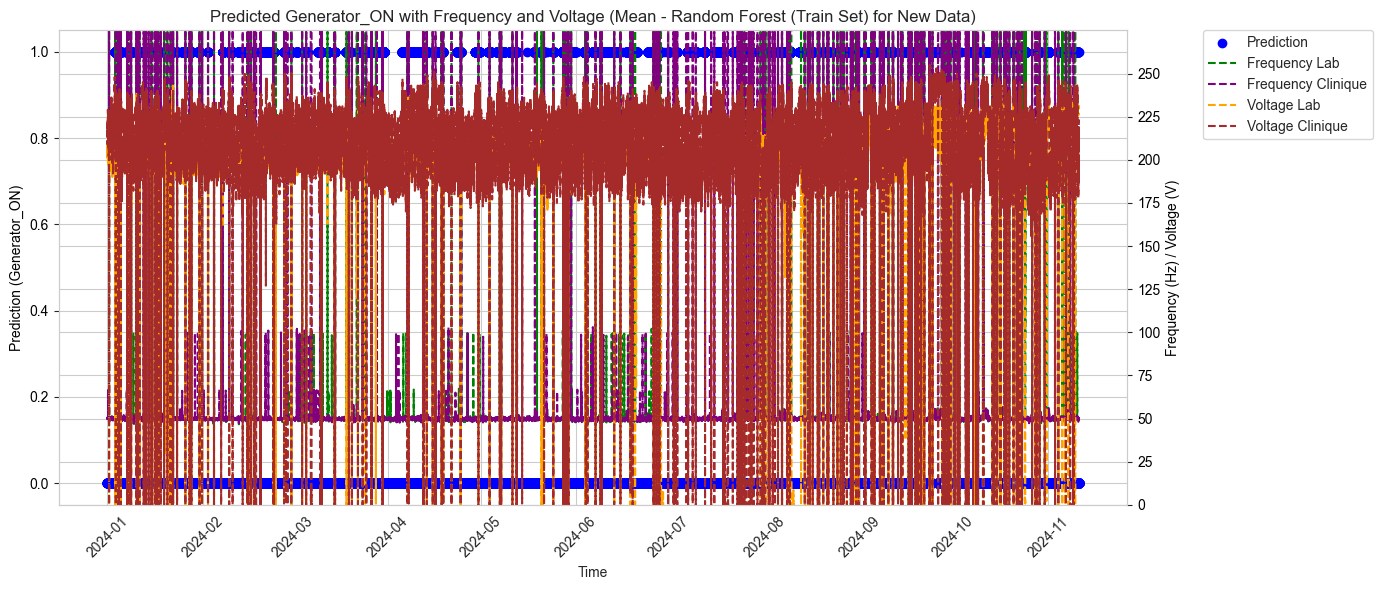

In [86]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2024, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:475: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


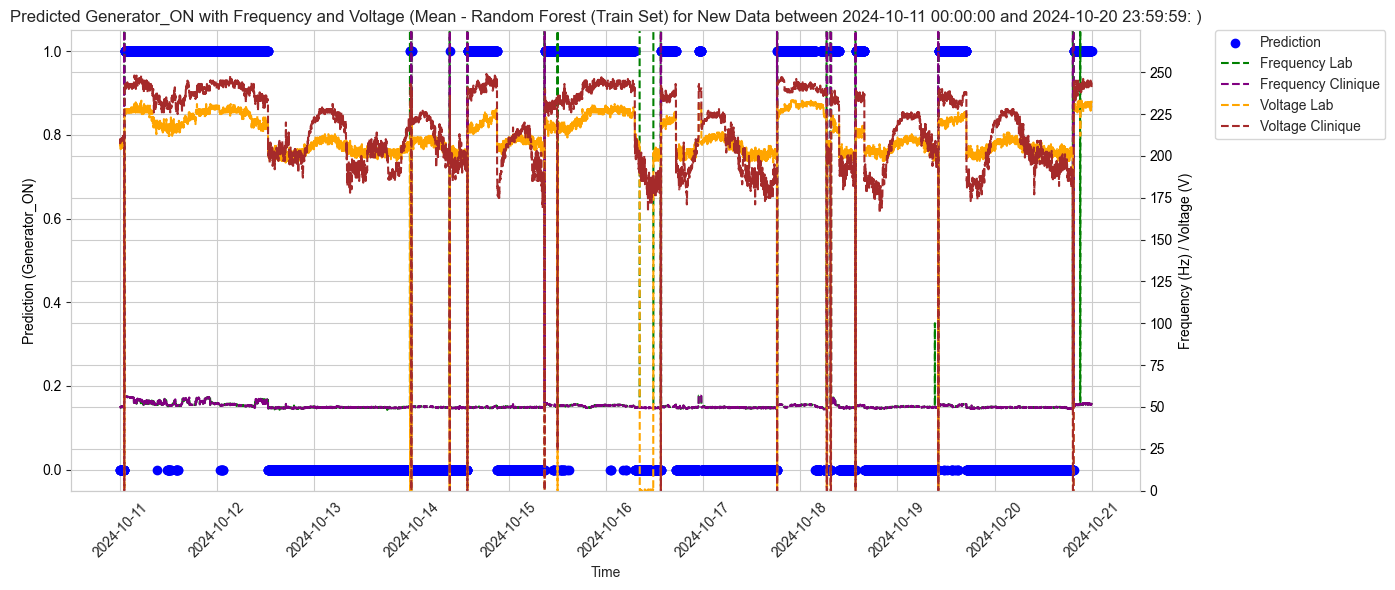

/Users/danielsitompul/Documents/GitHub/Generator_ML_Emission_Modeling/ModelingFunctions/GEMpythonlib/GEMpythonfunctions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[time_column] = pd.to_datetime(data[time_column], format='%Y-%m-%d %H:%M:%S')


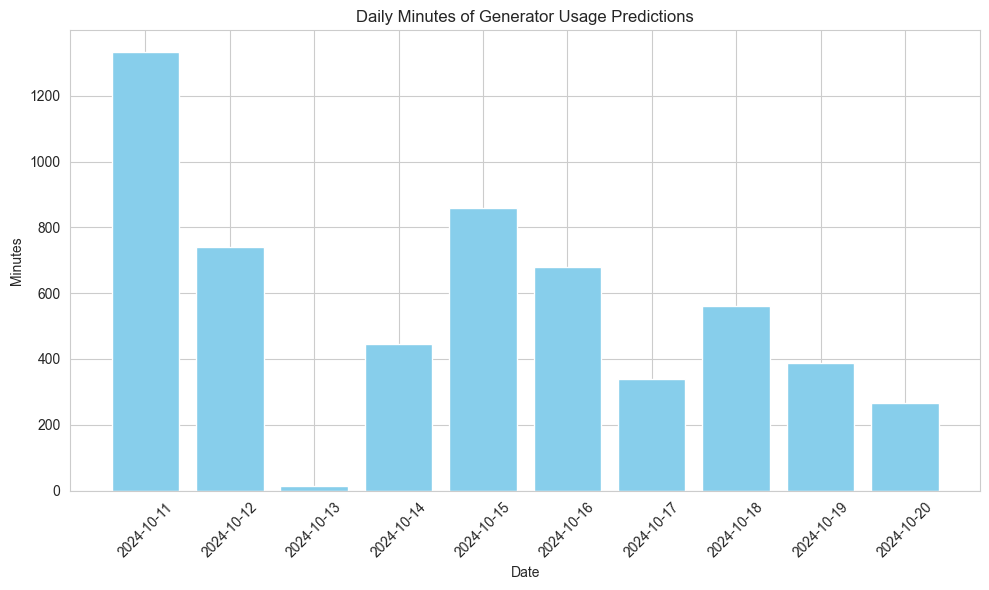

,Date,Count,Minutes,Hours
0,2024-10-11,666,1332,22.200000
1,2024-10-12,370,740,12.333333
2,2024-10-13,7,14,0.233333
3,2024-10-14,222,444,7.400000
4,2024-10-15,430,860,14.333333
5,2024-10-16,340,680,11.333333
6,2024-10-17,170,340,5.666667
7,2024-10-18,280,560,9.333333
8,2024-10-19,194,388,6.466667
9,2024-10-20,133,266,4.433333


##### PREDICTION RESULT #####
Predicted Minutes: 5624 minutes, or 93.73 hours within 240.00 hours


In [87]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2024)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2024['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2024) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

In [88]:
## CHECK : 4-11 November

## 6. Summary of Data

#### 6.1. Generator 2022 Data

In [89]:
year_summary, monthly_summary = generator_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

'Yearly Summary:'

,Metric,Value
0,Total Minutes Used (min),28878
1,Average Daily Usage (min),132.46789
2,Median Daily Usage (min),6.0
3,Highest Month (Total),Month 11 (6228 mins)
4,Lowest Month (Total),Month 5 (270 mins)


'Monthly Summary:'

,Month,Total Usage (min),Average Daily Usage (min),Max Daily Usage (min),Max Daily Usage (Date)
0,5,270,33.750000,127,2022-05-30
1,6,5530,92.166667,549,2022-06-06
2,7,3128,50.451613,194,2022-07-28
3,8,3170,51.129032,352,2022-08-25
4,9,4828,80.466667,277,2022-09-21
5,10,3676,59.290323,243,2022-10-30
6,11,6228,103.800000,405,2022-11-07
7,12,2048,33.032258,276,2022-12-05


#### 6.2. Generator 2023 Data

In [90]:
year_summary, monthly_summary = generator_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

'Yearly Summary:'

,Metric,Value
0,Total Minutes Used (min),113200
1,Average Daily Usage (min),310.136986
2,Median Daily Usage (min),302.0
3,Highest Month (Total),Month 12 (14056 mins)
4,Lowest Month (Total),Month 1 (2976 mins)


'Monthly Summary:'

,Month,Total Usage (min),Average Daily Usage (min),Max Daily Usage (min),Max Daily Usage (Date)
0,1,2976,48.000000,383,2023-01-08
1,2,4422,78.964286,352,2023-02-07
2,3,5000,80.645161,390,2023-03-12
3,4,12872,214.533333,488,2023-04-11
4,5,13516,218.000000,318,2023-05-29
5,6,13428,223.800000,363,2023-06-22
6,7,8388,135.290323,428,2023-07-05
7,8,12276,198.000000,434,2023-08-08
8,9,11912,198.533333,533,2023-09-05
9,10,4918,79.322581,397,2023-10-27


#### 6.3. Generator 2024 Data

In [91]:
year_summary, monthly_summary = generator_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

'Yearly Summary:'

,Metric,Value
0,Total Minutes Used (min),82944
1,Average Daily Usage (min),263.314286
2,Median Daily Usage (min),174.0
3,Highest Month (Total),Month 9 (15886 mins)
4,Lowest Month (Total),Month 11 (3540 mins)


'Monthly Summary:'

,Month,Total Usage (min),Average Daily Usage (min),Max Daily Usage (min),Max Daily Usage (Date)
0,1,7308,117.870968,340,2024-01-19
1,2,5284,91.103448,295,2024-02-27
2,3,5262,84.870968,332,2024-03-30
3,4,8110,135.166667,467,2024-04-15
4,5,5372,86.645161,389,2024-05-10
5,6,6442,107.366667,300,2024-06-04
6,7,5308,85.612903,320,2024-07-07
7,8,8102,130.677419,441,2024-08-20
8,9,15886,264.766667,720,2024-09-25
9,10,12330,198.870968,666,2024-10-11


## 7. Generator Power Calculation

In [92]:
# Constant Declaration of Hourly kwh average
kwh_hour = [
    6.747835296, 7.057838155, 8.16854183, 11.30196556, 11.21547191, 9.88189269, 11.22740354, 12.85224141, 14.05086424, 13.96076821,
    13.70200973, 13.46483643, 13.25040271, 12.23739568, 9.853452467, 11.13546578, 11.58039839, 9.594331892, 9.649361468,
    8.320364238, 6.779637969, 6.241952539, 6.125157442, 6.18646468
]

#### 7.1. Generator 2022 Power

In [93]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2022['power (kW)'] = test_data_2022.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2022[test_data_2022['prediction']]

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique,prediction,Date,Month,power (kW)
277,2022-05-28 09:14:00,50.0,50.0,213.0,216.0,2022-05-28 09:14:00,False,False,True,True,...,False,False,False,False,False,False,True,2022-05-28,5,0.465359
990,2022-05-29 09:00:00,50.1,50.1,216.0,218.0,2022-05-29 09:00:00,False,False,True,True,...,False,False,False,False,False,False,True,2022-05-29,5,0.465359
991,2022-05-29 09:02:00,50.3,50.3,213.0,215.0,2022-05-29 09:02:00,False,False,True,True,...,False,False,False,False,False,False,True,2022-05-29,5,0.465359
992,2022-05-29 09:04:00,50.3,50.3,216.0,218.0,2022-05-29 09:04:00,False,False,True,True,...,False,False,False,False,False,False,True,2022-05-29,5,0.465359
996,2022-05-29 09:12:00,50.3,50.3,214.0,216.0,2022-05-29 09:12:00,False,False,True,True,...,False,False,False,False,False,False,True,2022-05-29,5,0.465359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155290,2022-12-29 16:22:00,51.1,NaN,231.0,NaN,2022-12-29 16:22:00,False,False,True,False,...,False,False,False,False,False,False,True,2022-12-29,12,0.386013
155291,2022-12-29 16:24:00,51.2,NaN,233.0,NaN,2022-12-29 16:24:00,False,False,True,False,...,False,False,False,False,False,False,True,2022-12-29,12,0.386013
155292,2022-12-29 16:26:00,51.0,NaN,234.0,NaN,2022-12-29 16:26:00,False,False,True,False,...,False,False,False,False,False,False,True,2022-12-29,12,0.386013
155293,2022-12-29 16:28:00,51.1,NaN,232.0,NaN,2022-12-29 16:28:00,False,False,True,False,...,False,False,False,False,False,False,True,2022-12-29,12,0.386013


In [94]:
# Year 2022 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

'Yearly Summary:'

,Metric,Value
0,Total Power Used (kW),5445.4
1,Average Daily Usage (kW),24.98
2,Median Daily Usage (kW),1.02
3,Highest Month (Total),Month 11 (1195.95 kW)
4,Lowest Month (Total),Month 5 (61.11 kW)


'Monthly Summary:'

,Month,Total Usage (kW),Average Daily Usage (kW),Max Daily Usage (kW),Max Daily Usage (Date)
0,5,61.11,15.28,57.53,2022-05-30
1,6,1058.49,35.28,203.53,2022-06-06
2,7,522.44,16.85,77.81,2022-07-09
3,8,514.09,16.58,143.55,2022-08-25
4,9,935.54,31.18,113.25,2022-09-21
5,10,723.84,23.35,103.34,2022-10-30
6,11,1195.95,39.86,155.18,2022-11-25
7,12,433.95,14.00,116.33,2022-12-05


#### 7.2. Generator 2023 Power

In [95]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2023['power (kW)'] = test_data_2023.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2023[test_data_2023['prediction']]

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique,prediction,Date,Month,power (kW)
1690,2023-01-03 08:20:00,51.2,51.2,237.0,239.0,2023-01-03 08:20:00,False,False,True,True,...,True,True,False,False,False,False,True,2023-01-03,1,0.468362
1691,2023-01-03 08:22:00,50.9,51.0,235.0,237.0,2023-01-03 08:22:00,False,False,True,True,...,False,False,False,False,True,True,True,2023-01-03,1,0.468362
1692,2023-01-03 08:24:00,50.9,50.9,234.0,236.0,2023-01-03 08:24:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-01-03,1,0.468362
1693,2023-01-03 08:26:00,50.9,50.8,233.0,236.0,2023-01-03 08:26:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-01-03,1,0.468362
1694,2023-01-03 08:28:00,50.7,50.8,233.0,231.0,2023-01-03 08:28:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-01-03,1,0.468362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266281,2023-12-30 10:00:00,50.9,50.9,213.0,230.0,2023-12-30 10:00:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-12-30,12,0.456734
266282,2023-12-30 10:02:00,51.2,51.3,209.0,230.0,2023-12-30 10:02:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-12-30,12,0.456734
266283,2023-12-30 10:02:00,51.2,51.3,209.0,230.0,2023-12-30 10:02:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-12-30,12,0.456734
266284,2023-12-30 10:04:00,51.1,51.2,213.0,231.0,2023-12-30 10:04:00,False,False,True,True,...,False,False,False,False,False,False,True,2023-12-30,12,0.456734


In [96]:
# Year 2023 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

'Yearly Summary:'

,Metric,Value
0,Total Power Used (kW),22294.77
1,Average Daily Usage (kW),61.08
2,Median Daily Usage (kW),60.68
3,Highest Month (Total),Month 5 (2830.83 kW)
4,Lowest Month (Total),Month 1 (571.2 kW)


'Monthly Summary:'

,Month,Total Usage (kW),Average Daily Usage (kW),Max Daily Usage (kW),Max Daily Usage (Date)
0,1,571.20,18.43,150.45,2023-01-08
1,2,911.07,32.54,144.18,2023-02-07
2,3,969.49,31.27,145.24,2023-03-12
3,4,2635.32,87.84,190.79,2023-04-11
4,5,2830.83,91.32,132.65,2023-05-29
5,6,2798.46,93.28,142.69,2023-06-22
6,7,1732.21,55.88,155.19,2023-07-05
7,8,2350.87,75.83,152.06,2023-08-18
8,9,2374.75,79.16,200.91,2023-09-05
9,10,969.79,31.28,149.74,2023-10-27


#### 7.3. Generator 2024 Power

In [97]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2024['power (kW)'] = test_data_2024.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2024[test_data_2024['prediction']]

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique,prediction,Date,Month,power (kW)
1708,2024-01-03 08:56:00,50.3,50.5,216.0,243.0,2024-01-03 08:56:00,False,False,True,True,...,True,True,False,False,False,False,True,2024-01-03,1,0.468362
1709,2024-01-03 08:58:00,51.0,50.8,219.0,245.0,2024-01-03 08:58:00,False,False,True,True,...,False,False,False,False,True,True,True,2024-01-03,1,0.468362
1710,2024-01-03 09:00:00,50.8,50.8,222.0,245.0,2024-01-03 09:00:00,False,False,True,True,...,False,False,False,False,False,False,True,2024-01-03,1,0.465359
1711,2024-01-03 09:02:00,50.6,50.6,216.0,248.0,2024-01-03 09:02:00,False,False,True,True,...,False,False,False,False,False,False,True,2024-01-03,1,0.465359
1712,2024-01-03 09:04:00,50.5,50.5,216.0,248.0,2024-01-03 09:04:00,False,False,True,True,...,False,False,False,False,False,False,True,2024-01-03,1,0.465359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226647,2024-11-10 19:52:00,50.0,49.9,227.0,206.0,2024-11-10 19:52:00,False,False,True,False,...,False,False,False,False,False,True,True,2024-11-10,11,0.277345
226648,2024-11-10 19:54:00,50.0,50.0,227.0,212.0,2024-11-10 19:54:00,False,False,True,True,...,False,False,False,False,False,False,True,2024-11-10,11,0.277345
226649,2024-11-10 19:56:00,50.2,49.3,227.0,202.0,2024-11-10 19:56:00,False,False,True,False,...,False,False,False,False,False,False,True,2024-11-10,11,0.277345
226650,2024-11-10 19:58:00,50.0,49.3,227.0,193.0,2024-11-10 19:58:00,False,False,True,False,...,False,False,False,False,False,False,True,2024-11-10,11,0.277345


In [98]:
# Year 2024 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

'Yearly Summary:'

,Metric,Value
0,Total Power Used (kW),15322.59
1,Average Daily Usage (kW),48.64
2,Median Daily Usage (kW),28.94
3,Highest Month (Total),Month 9 (2745.76 kW)
4,Lowest Month (Total),Month 11 (693.58 kW)


'Monthly Summary:'

,Month,Total Usage (kW),Average Daily Usage (kW),Max Daily Usage (kW),Max Daily Usage (Date)
0,1,1335.60,43.08,123.74,2024-01-19
1,2,972.23,33.53,122.42,2024-02-27
2,3,1082.42,34.92,132.66,2024-03-22
3,4,1596.87,53.23,160.08,2024-04-15
4,5,1055.84,34.06,130.77,2024-05-10
5,6,1273.37,42.45,122.28,2024-06-04
6,7,976.47,31.50,131.35,2024-07-07
7,8,1444.78,46.61,176.15,2024-08-20
8,9,2745.76,91.53,244.59,2024-09-25
9,10,2145.67,69.22,228.35,2024-10-11


## 8. Generator Emission Calculation

In [99]:
# Constant Declaration of Emission index

#Assuming Un-Controlled NOx
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

#### 8.1. Generator 2022 Emission

In [100]:
test_data_2022 = calculate_emissions(test_data_2022)

test_data_2022[test_data_2022['prediction']]

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Prev_High_delta_volt_clinique,prediction,Date,Month,power (kW),NOx Emission (g),CO Emission (g),SOx Emission (g),CO2 Emission (g),PM Emission (g)
277,2022-05-28 09:14:00,50.0,50.0,213.0,216.0,2022-05-28 09:14:00,False,False,True,True,...,False,True,2022-05-28,5,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
990,2022-05-29 09:00:00,50.1,50.1,216.0,218.0,2022-05-29 09:00:00,False,False,True,True,...,False,True,2022-05-29,5,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
991,2022-05-29 09:02:00,50.3,50.3,213.0,215.0,2022-05-29 09:02:00,False,False,True,True,...,False,True,2022-05-29,5,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
992,2022-05-29 09:04:00,50.3,50.3,216.0,218.0,2022-05-29 09:04:00,False,False,True,True,...,False,True,2022-05-29,5,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
996,2022-05-29 09:12:00,50.3,50.3,214.0,216.0,2022-05-29 09:12:00,False,False,True,True,...,False,True,2022-05-29,5,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155290,2022-12-29 16:22:00,51.1,NaN,231.0,NaN,2022-12-29 16:22:00,False,False,True,False,...,False,True,2022-12-29,12,0.386013,5.635178,1.291395,1.899525,272.366945,0.164359
155291,2022-12-29 16:24:00,51.2,NaN,233.0,NaN,2022-12-29 16:24:00,False,False,True,False,...,False,True,2022-12-29,12,0.386013,5.635178,1.291395,1.899525,272.366945,0.164359
155292,2022-12-29 16:26:00,51.0,NaN,234.0,NaN,2022-12-29 16:26:00,False,False,True,False,...,False,True,2022-12-29,12,0.386013,5.635178,1.291395,1.899525,272.366945,0.164359
155293,2022-12-29 16:28:00,51.1,NaN,232.0,NaN,2022-12-29 16:28:00,False,False,True,False,...,False,True,2022-12-29,12,0.386013,5.635178,1.291395,1.899525,272.366945,0.164359


In [101]:
generator_emission_summary(test_data_2022)

'Yearly Summary NOx emission:'

,Metric,Value
0,Total year NOx Emission (g),79494.19
1,Average Daily NOx Emission (g),364.65
2,Median Daily NOx Emission (g),14.89
3,Highest Month NOx Emission (Total),Month 11 (17458.94 g)
4,Lowest Month NOx Emission (Total),Month 5 (892.11 g)


'Monthly Summary  NOx emission:'

,Month,Total NOx Emission (g),Average Daily NOx Emission (g),Max Daily NOx Emission (g),Max Daily NOx Emission (Date)
0,5,892.11,223.03,839.86,2022-05-30
1,6,15452.27,515.08,2971.21,2022-06-06
2,7,7626.76,246.02,1135.86,2022-07-09
3,8,7504.85,242.09,2095.56,2022-08-25
4,9,13657.40,455.25,1653.21,2022-09-21
5,10,10566.94,340.87,1508.61,2022-10-30
6,11,17458.94,581.96,2265.38,2022-11-25
7,12,6334.93,204.35,1698.28,2022-12-05


'Yearly Summary CO emission:'

...

,Month,Total CO2 Emission (g),Average Daily CO2 Emission (g),Max Daily CO2 Emission (g),Max Daily CO2 Emission (Date)
0,5,43118.71,10779.68,40593.30,2022-05-30
1,6,746859.59,24895.32,143608.71,2022-06-06
2,7,368626.72,11891.18,54899.83,2022-07-09
3,8,362734.48,11701.11,101285.54,2022-08-25
4,9,660107.43,22003.58,79905.20,2022-09-21
5,10,510735.62,16475.34,72916.33,2022-10-30
6,11,843848.53,28128.28,109493.22,2022-11-25
7,12,306188.06,9877.03,82083.50,2022-12-05


'Yearly Summary PM emission:'

,Metric,Value
0,Total year PM Emission (g),2318.58
1,Average Daily PM Emission (g),10.64
2,Median Daily PM Emission (g),0.43
3,Highest Month PM Emission (Total),Month 11 (509.22 g)
4,Lowest Month PM Emission (Total),Month 5 (26.02 g)


'Monthly Summary  PM emission:'

,Month,Total PM Emission (g),Average Daily PM Emission (g),Max Daily PM Emission (g),Max Daily PM Emission (Date)
0,5,26.02,6.50,24.50,2022-05-30
1,6,450.69,15.02,86.66,2022-06-06
2,7,222.45,7.18,33.13,2022-07-09
3,8,218.89,7.06,61.12,2022-08-25
4,9,398.34,13.28,48.22,2022-09-21
5,10,308.20,9.94,44.00,2022-10-30
6,11,509.22,16.97,66.07,2022-11-25
7,12,184.77,5.96,49.53,2022-12-05


#### 8.2. Generator 2023 Emission

In [102]:
test_data_2023 = calculate_emissions(test_data_2023)

test_data_2023[test_data_2023['prediction']]

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Prev_High_delta_volt_clinique,prediction,Date,Month,power (kW),NOx Emission (g),CO Emission (g),SOx Emission (g),CO2 Emission (g),PM Emission (g)
1690,2023-01-03 08:20:00,51.2,51.2,237.0,239.0,2023-01-03 08:20:00,False,False,True,True,...,False,True,2023-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
1691,2023-01-03 08:22:00,50.9,51.0,235.0,237.0,2023-01-03 08:22:00,False,False,True,True,...,True,True,2023-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
1692,2023-01-03 08:24:00,50.9,50.9,234.0,236.0,2023-01-03 08:24:00,False,False,True,True,...,False,True,2023-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
1693,2023-01-03 08:26:00,50.9,50.8,233.0,236.0,2023-01-03 08:26:00,False,False,True,True,...,False,True,2023-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
1694,2023-01-03 08:28:00,50.7,50.8,233.0,231.0,2023-01-03 08:28:00,False,False,True,True,...,False,True,2023-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266281,2023-12-30 10:00:00,50.9,50.9,213.0,230.0,2023-12-30 10:00:00,False,False,True,True,...,False,True,2023-12-30,12,0.456734,6.667583,1.527988,2.247531,322.266506,0.194471
266282,2023-12-30 10:02:00,51.2,51.3,209.0,230.0,2023-12-30 10:02:00,False,False,True,True,...,False,True,2023-12-30,12,0.456734,6.667583,1.527988,2.247531,322.266506,0.194471
266283,2023-12-30 10:02:00,51.2,51.3,209.0,230.0,2023-12-30 10:02:00,False,False,True,True,...,False,True,2023-12-30,12,0.456734,6.667583,1.527988,2.247531,322.266506,0.194471
266284,2023-12-30 10:04:00,51.1,51.2,213.0,231.0,2023-12-30 10:04:00,False,False,True,True,...,False,True,2023-12-30,12,0.456734,6.667583,1.527988,2.247531,322.266506,0.194471


In [103]:
generator_emission_summary(test_data_2023)

'Yearly Summary NOx emission:'

,Metric,Value
0,Total year NOx Emission (g),325468.15
1,Average Daily NOx Emission (g),891.69
2,Median Daily NOx Emission (g),885.83
3,Highest Month NOx Emission (Total),Month 5 (41325.58 g)
4,Lowest Month NOx Emission (Total),Month 1 (8338.68 g)


'Monthly Summary  NOx emission:'

,Month,Total NOx Emission (g),Average Daily NOx Emission (g),Max Daily NOx Emission (g),Max Daily NOx Emission (Date)
0,1,8338.68,268.99,2196.34,2023-01-08
1,2,13300.19,475.01,2104.77,2023-02-07
2,3,14153.06,456.55,2120.22,2023-03-12
3,4,38471.40,1282.38,2785.24,2023-04-11
4,5,41325.58,1333.08,1936.49,2023-05-29
5,6,40853.12,1361.77,2083.03,2023-06-22
6,7,25287.55,815.73,2265.53,2023-07-05
7,8,34318.94,1107.06,2219.80,2023-08-18
8,9,34667.56,1155.59,2933.00,2023-09-05
9,10,14157.35,456.69,2185.93,2023-10-27


'Yearly Summary CO emission:'

...

,Month,Total CO2 Emission (g),Average Daily CO2 Emission (g),Max Daily CO2 Emission (g),Max Daily CO2 Emission (Date)
0,1,403036.17,13001.17,106156.39,2023-01-08
1,2,642842.57,22958.66,101730.48,2023-02-07
2,3,684064.69,22066.60,102477.44,2023-03-12
3,4,1859451.06,61981.70,134620.15,2023-04-11
4,5,1997403.08,64432.36,93597.02,2023-05-29
5,6,1974567.28,65818.91,100679.96,2023-06-22
6,7,1222231.48,39426.82,109500.75,2023-07-05
7,8,1658748.58,53508.02,107290.34,2023-08-18
8,9,1675598.90,55853.30,141761.74,2023-09-05
9,10,684271.85,22073.29,105653.19,2023-10-27


'Yearly Summary PM emission:'

,Metric,Value
0,Total year PM Emission (g),9492.82
1,Average Daily PM Emission (g),26.01
2,Median Daily PM Emission (g),25.84
3,Highest Month PM Emission (Total),Month 5 (1205.33 g)
4,Lowest Month PM Emission (Total),Month 1 (243.21 g)


'Monthly Summary  PM emission:'

,Month,Total PM Emission (g),Average Daily PM Emission (g),Max Daily PM Emission (g),Max Daily PM Emission (Date)
0,1,243.21,7.85,64.06,2023-01-08
1,2,387.92,13.85,61.39,2023-02-07
2,3,412.80,13.32,61.84,2023-03-12
3,4,1122.08,37.40,81.24,2023-04-11
4,5,1205.33,38.88,56.48,2023-05-29
5,6,1191.55,39.72,60.76,2023-06-22
6,7,737.55,23.79,66.08,2023-07-05
7,8,1000.97,32.29,64.74,2023-08-18
8,9,1011.14,33.70,85.55,2023-09-05
9,10,412.92,13.32,63.76,2023-10-27


#### 8.3. Generator 2024 Emission

In [104]:
test_data_2024 = calculate_emissions(test_data_2024)

test_data_2024[test_data_2024['prediction']]

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),time,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Prev_High_delta_volt_clinique,prediction,Date,Month,power (kW),NOx Emission (g),CO Emission (g),SOx Emission (g),CO2 Emission (g),PM Emission (g)
1708,2024-01-03 08:56:00,50.3,50.5,216.0,243.0,2024-01-03 08:56:00,False,False,True,True,...,False,True,2024-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
1709,2024-01-03 08:58:00,51.0,50.8,219.0,245.0,2024-01-03 08:58:00,False,False,True,True,...,True,True,2024-01-03,1,0.468362,6.837340,1.566890,2.304753,330.471443,0.199422
1710,2024-01-03 09:00:00,50.8,50.8,222.0,245.0,2024-01-03 09:00:00,False,False,True,True,...,False,True,2024-01-03,1,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
1711,2024-01-03 09:02:00,50.6,50.6,216.0,248.0,2024-01-03 09:02:00,False,False,True,True,...,False,True,2024-01-03,1,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
1712,2024-01-03 09:04:00,50.5,50.5,216.0,248.0,2024-01-03 09:04:00,False,False,True,True,...,False,True,2024-01-03,1,0.465359,6.793498,1.556843,2.289975,328.352415,0.198144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226647,2024-11-10 19:52:00,50.0,49.9,227.0,206.0,2024-11-10 19:52:00,False,False,True,False,...,True,True,2024-11-10,11,0.277345,4.048802,0.927850,1.364784,195.692075,0.118090
226648,2024-11-10 19:54:00,50.0,50.0,227.0,212.0,2024-11-10 19:54:00,False,False,True,True,...,False,True,2024-11-10,11,0.277345,4.048802,0.927850,1.364784,195.692075,0.118090
226649,2024-11-10 19:56:00,50.2,49.3,227.0,202.0,2024-11-10 19:56:00,False,False,True,False,...,False,True,2024-11-10,11,0.277345,4.048802,0.927850,1.364784,195.692075,0.118090
226650,2024-11-10 19:58:00,50.0,49.3,227.0,193.0,2024-11-10 19:58:00,False,False,True,False,...,False,True,2024-11-10,11,0.277345,4.048802,0.927850,1.364784,195.692075,0.118090


In [105]:
generator_emission_summary(test_data_2024)

'Yearly Summary NOx emission:'

,Metric,Value
0,Total year NOx Emission (g),223685.36
1,Average Daily NOx Emission (g),710.11
2,Median Daily NOx Emission (g),422.46
3,Highest Month NOx Emission (Total),Month 9 (40083.66 g)
4,Lowest Month NOx Emission (Total),Month 11 (10125.19 g)


'Monthly Summary  NOx emission:'

,Month,Total NOx Emission (g),Average Daily NOx Emission (g),Max Daily NOx Emission (g),Max Daily NOx Emission (Date)
0,1,19497.59,628.95,1806.45,2024-01-19
1,2,14192.98,489.41,1787.14,2024-02-27
2,3,15801.67,509.73,1936.63,2024-03-22
3,4,23311.81,777.06,2336.96,2024-04-15
4,5,15413.53,497.21,1909.09,2024-05-10
5,6,18589.16,619.64,1785.06,2024-06-04
6,7,14254.90,459.84,1917.54,2024-07-07
7,8,21091.54,680.37,2571.44,2024-08-20
8,9,40083.66,1336.12,3570.57,2024-09-25
9,10,31323.36,1010.43,3333.57,2024-10-11


'Yearly Summary CO emission:'

...

,Month,Total CO2 Emission (g),Average Daily CO2 Emission (g),Max Daily CO2 Emission (g),Max Daily CO2 Emission (Date)
0,1,942383.53,30399.47,87311.65,2024-01-19
1,2,685993.89,23654.96,86378.51,2024-02-27
2,3,763747.31,24637.01,93603.99,2024-03-22
3,4,1126737.31,37557.91,112953.05,2024-04-15
4,5,744987.23,24031.85,92272.56,2024-05-10
5,6,898476.07,29949.20,86278.12,2024-06-04
6,7,688986.64,22225.38,92681.22,2024-07-07
7,8,1019424.22,32884.65,124286.39,2024-08-20
8,9,1937376.76,64579.23,172577.37,2024-09-25
9,10,1513962.28,48837.49,161122.76,2024-10-11


'Yearly Summary PM emission:'

,Metric,Value
0,Total year PM Emission (g),6524.16
1,Average Daily PM Emission (g),20.71
2,Median Daily PM Emission (g),12.32
3,Highest Month PM Emission (Total),Month 9 (1169.11 g)
4,Lowest Month PM Emission (Total),Month 11 (295.32 g)


'Monthly Summary  PM emission:'

,Month,Total PM Emission (g),Average Daily PM Emission (g),Max Daily PM Emission (g),Max Daily PM Emission (Date)
0,1,568.68,18.34,52.69,2024-01-19
1,2,413.96,14.27,52.12,2024-02-27
2,3,460.88,14.87,56.49,2024-03-22
3,4,679.93,22.66,68.16,2024-04-15
4,5,449.56,14.50,55.68,2024-05-10
5,6,542.18,18.07,52.06,2024-06-04
6,7,415.77,13.41,55.93,2024-07-07
7,8,615.17,19.84,75.00,2024-08-20
8,9,1169.11,38.97,104.14,2024-09-25
9,10,913.60,29.47,97.23,2024-10-11
